# We used ChatGPt and Claude to generate and improve our code. All provided codes were manually reviewed and understood before using them. 
# Below are the detailed information on how the previous Gen AI tools were used.

# Important Note: We have created a project folder for codes in GPT, and Claude not to need to write everthing each time we ask about generating a code. So, the history of the conversation and codes were already saved there. 

Impoting Data from Manifesto Project

In [9]:
import os
print(os.getcwd()) # to ensure we are in the correct directory.

/Users/mmoheebahmed/Desktop/PhD_UCD/Modules/Second Term/AI&LLMs/Project


# Figure 1: Asylum Applications among Top 5 EU Countries from 2014 to 2025

In [10]:
# for our first figure, we were working with eurostat data on refugees. here we just read the data, and print without any support from AI since it is an easy task. 
import pandas as pd

top_countries_refugee = pd.read_csv(
    "figure_1_eurostat.csv",
    sep=";", # the separator in the csv file is a semicolon, not a comma.
    na_values=":", # in the csv file, missing values are represented by a colon, so we specify that to pandas.
    skiprows=1 # the first row of the csv file is not part of the data, so we skip it.
)

print(top_countries_refugee.head())
print(top_countries_refugee.columns)

# so we need now to rename the country colums so to be easy to understand and create a function to calculate the top ten countries with the highest number of refugees. we will use the GPT to help us with that.

  Country   2014   2015   2016   2017   2018   2019   2020   2021    2022  \
0      AT  28035  88160  42255  24715  13710  12860  14760  39900  112245   
1      BE  22710  44665  18280  18340  22530  27460  16710  24970   36740   
2      BG  11080  20390  19420   3695   2535   2150   3525  11000   20390   
3      CH  23560  39445  27140  18015  15160  14195  10990  14850   24440   
4      CY   1745   2265   2940   4600   7765  13650   7495  13670   22190   

    2023   2024   2025  
0  59210  25330  16245  
1  35160  39130  34355  
2  22510  12260   3895  
3  30110  27615  25625  
4  11910   9185   4610  
Index(['Country', '2014', '2015', '2016', '2017', '2018', '2019', '2020',
       '2021', '2022', '2023', '2024', '2025'],
      dtype='str')


In [11]:
# we asked the GPT that we wanted to claculate the top ten countries with the highest number of refugees for each year, and we gave it a screenshot of the data, and we asked how can do that? 
# GPT gave us the following code, first we need to create a year colum that contains the years from 2014 to 2025, and then we need to convert the year columns to numeric, and if there are any errors (like missing values), we coerce them to NaN.

years = [str(y) for y in range(2014, 2026)] # by wriring the 2026, to ensure that 2025 is included in the list of years.
top_countries_refugee[years] = top_countries_refugee[years].apply(pd.to_numeric, errors="coerce") 

In [12]:
top_countries_refugee["total_2014_2025"] = top_countries_refugee[years].sum(axis=1) # to create a new column that contains the total number of refugees for each country from 2014 to 2025.

top10 = top_countries_refugee.nlargest(10, "total_2014_2025") # to get the top ten countries with the highest number of refugees from 2014 to 2025. 

print(top10[["Country", "total_2014_2025"]]) 

   Country  total_2014_2025
6       DE        3323445.0
12      FR        1459095.0
17      IT        1096310.0
10      ES         990220.0
9       EL         582455.0
0       AT         477425.0
29      SE         458670.0
1       BE         341050.0
24      NL         335540.0
3       CH         271145.0


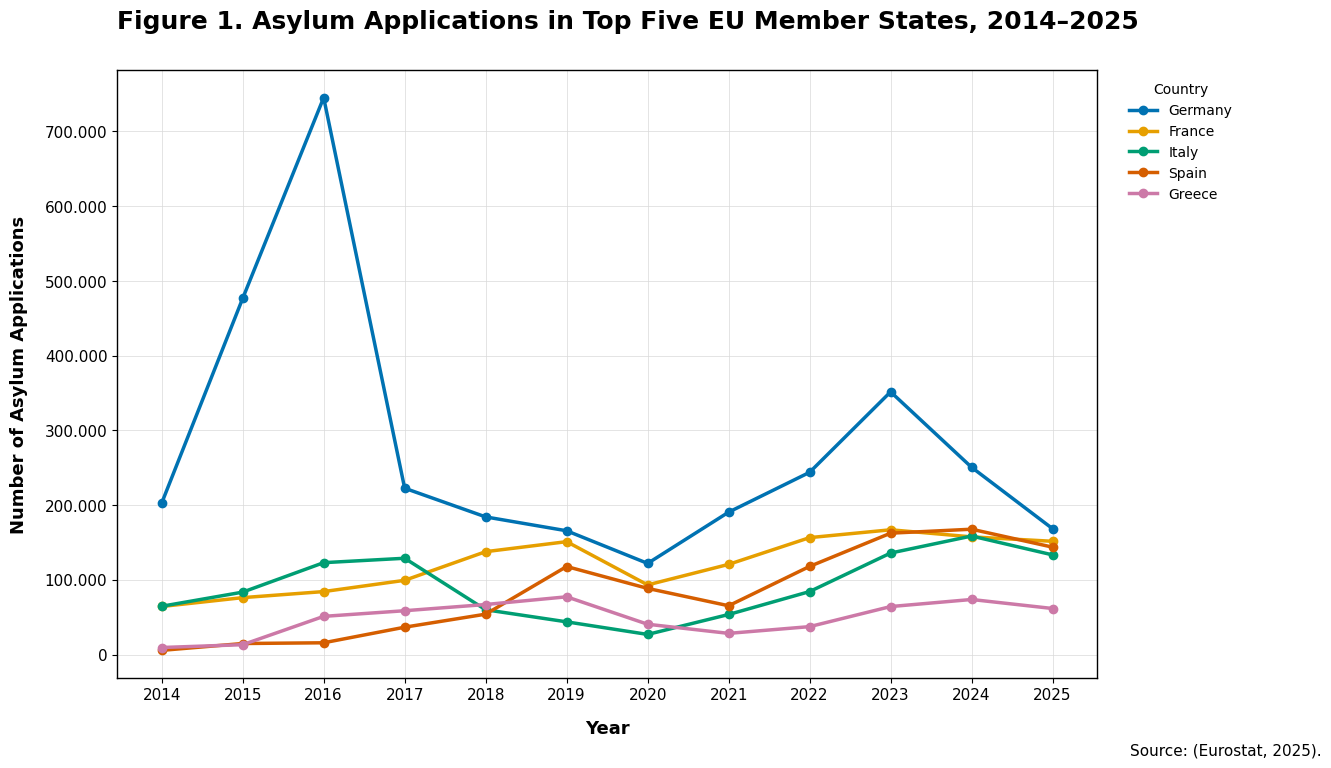

In [13]:
# After that we decided to plot only the top five countries, since it will be easier to read and understand the figure. 
# One team member had a similiar code from previous project which include a alot of the aesestic elements that we wanted to include in our figure,
# so we provided the GPT with the current prompt: we want to create a trend plot for the top five countries, attached is a screenshot of the data, and we want to use the same aesetic elements that are included in the code below
# and we want to modify that code to fit our data and our needs. 

# GPT gave us the following code, which we modified to fit our data and our needs.


import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

top5 = top10.sort_values("total_2014_2025", ascending=False).head(5)

country_names = {
    "DE": "Germany",
    "FR": "France",
    "IT": "Italy",
    "ES": "Spain",
    "EL": "Greece"
}

cb_colors = {
    "DE": "#0072B2",
    "FR": "#E69F00",
    "IT": "#009E73",
    "ES": "#D55E00",
    "EL": "#CC79A7"
}

def euro_format(x, pos):
    return f"{int(x):,}".replace(",", ".")

figure_1, ax = plt.subplots(figsize=(14, 8))

figure_1.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.grid(
    True,
    which="major",
    axis="both",
    linestyle="-",
    linewidth=0.5,
    color="#d9d9d9"
)

# ✅ Plot
for _, row in top5.iterrows():
    code = row["Country"]
    ax.plot(
        years,
        row[years],
        marker="o",
        linewidth=2.5,
        label=country_names.get(code, code),
        color=cb_colors.get(code, None)
    )

ax.set_title(
    "Figure 1. Asylum Applications in Top Five EU Member States, 2014–2025",
    loc="left",
    fontsize=18,
    color="black",
    weight="bold",
    pad=30
)

ax.set_xlabel("Year", fontsize=13, color="black", labelpad=12)
ax.set_ylabel("Number of Asylum Applications", fontsize=13, color="black", labelpad=12)

ax.tick_params(axis="x", labelrotation=0, labelsize=11, colors="black")
ax.tick_params(axis="y", labelsize=11, colors="black")

ax.yaxis.set_major_formatter(FuncFormatter(euro_format))

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1)

ax.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)

figure_1.text(
    0.98, 0.02,
    "Source: (Eurostat, 2025).",
    ha="right",
    va="bottom",
    fontsize=11,
    color="black"
)

plt.subplots_adjust(left=0.12, right=0.82, top=0.88, bottom=0.12)

figure_1.savefig("figure_1.pdf", bbox_inches="tight")
figure_1.savefig("figure_1.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

# Figure 2: Country of origion of the three top refugee groups in Germany

In [14]:
# for our figure 2, we used a dataframe from the  German Federal Office for Migration and Refugees(BAMF).
# we did the same steps as we did for the first figure, we read the data, and we printed it without any support from AI since it is an easy task.   

figure_2_bamf = pd.read_csv(
    "figure_2_bamf.csv",
    sep=";",
    na_values=":",
    skiprows=1
)

FileNotFoundError: [Errno 2] No such file or directory: 'figure_2_bamf.csv'

In [ ]:
figure_2_bamf.info()

<class 'pandas.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Afghanistan  16 non-null     str    
 1   31382.0      13 non-null     float64
 2   127012.0     11 non-null     float64
 3   31623.0      10 non-null     float64
 4   9942.0       10 non-null     float64
 5   9522.0       9 non-null      float64
 6   9901.0       8 non-null      float64
 7   23276.0      8 non-null      float64
 8   36358.0      9 non-null      float64
 9   51275.0      8 non-null      float64
 10  34149.0      10 non-null     float64
dtypes: float64(10), str(1)
memory usage: 1.6 KB


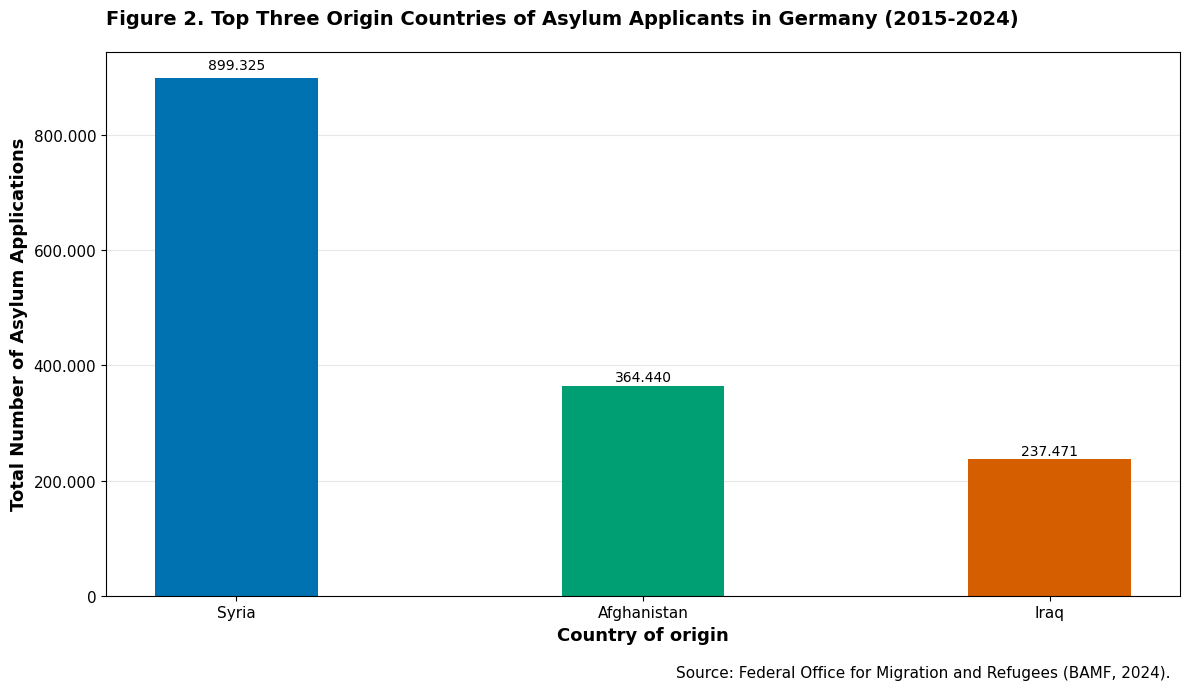

In [ ]:
# this figure was quite challenging, since the data was not in the right format, 
# and we had to do a lot of data cleaning and manipulation to get it in the right format figure_2_bamf for plotting.
# we asked the GPT to help us with this prompt: 
# "we have this dataset (in the attached screenshot), we want to plot the top three origin countries of asylum applicants in Germany from 2015 to 2024 by create a similiar plot like the one for our figure_1,
# but this time as bar plot, and most important is that there are no year or country column, and the data is in a wide format and in German, so we need to do some data cleaning and manipulation to get it in the right format for plotting, 
# so give us the code to clean and to plot the first top three countries in bar plot?"

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


df = figure_2_bamf.copy()

df = df.rename(columns={df.columns[0]: "country"}) # to fix the first column name to "country"
df.columns = df.columns.astype(str).str.strip()
df["country"] = df["country"].astype(str).str.strip()

year_cols = [col for col in df.columns if col.isdigit()] # to select columns that are years (i.e., columns that are digits)

for col in year_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce") # convert the year to nummeric. 

drop_rows = ["Ungeklärt", "Unknown", "Gesamt", "Total"] # remove non country. for our project, it doesnt matter since we wanted to include only the top three or five countries. 
df = df[~df["country"].isin(drop_rows)].copy()


df["total_applications"] = df[year_cols].sum(axis=1) # we wanted here to aggregate the total number of applications across all years for each country, so we sum across the year columns for each row (country) and create a new column "total_applications" to store this aggregated value.

df_top3 = df.nlargest(3, "total_applications").copy() # select the top three countries with the highest total number of applications across all years.

df_top3 = df_top3.sort_values("total_applications", ascending=False) # sort the top three countries in descending order based on the total number of applications. 

def euro_format(x, pos): # to change the german format of the numbers to the english format. 

    return f"{int(x):,}".replace(",", ".")

translation_dict = {
    "Syrien": "Syria",
    "Afghanistan": "Afghanistan",
    "Türkei": "Turkey",
    "Irak": "Iraq",
    "Iran": "Iran",
    "Russische Föderation": "Russia"
} # to translate country names to English


# here is the main code for our bar plot (figure 2).

df_top3["country"] = df_top3["country"].replace(translation_dict)

fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor("white")
ax.set_facecolor("white")

bars = ax.bar(
    df_top3["country"],
    df_top3["total_applications"],
    color=["#0072B2", "#009E73", "#D55E00"],
    width = 0.4
)

ax.set_title(
    "Figure 2. Top Three Origin Countries of Asylum Applicants in Germany (2015-2024)",
    loc="left",
    fontsize=14,
    weight="bold",
    pad=20
)

ax.set_xlabel("Country of origin", fontsize=13, weight="bold")
ax.set_ylabel("Total Number of Asylum Applications", fontsize=13, weight="bold")

ax.grid(True, axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.yaxis.set_major_formatter(FuncFormatter(euro_format))
ax.tick_params(axis="x", labelsize=11)
ax.tick_params(axis="y", labelsize=11)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + (height * 0.01),
        euro_format(height, None),
        ha="center",
        va="bottom",
        fontsize=10
    )

fig.text(
    0.98, 0.02,
    "Source: Federal Office for Migration and Refugees (BAMF, 2024).",
    ha="right",
    va="bottom",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

fig.savefig("figure_2_top3_aggregated.pdf", bbox_inches="tight")
fig.savefig("figure_2_top3_aggregated.png", dpi=300, bbox_inches="tight", facecolor="white")

plt.show()

# Figure 3: Migraion Related Sentences in the Corpus Over Time

In [ ]:
# After running our migration idenfitication classification, we wanted to check the proportion of migration to non-migration in our dataset. 
# we did this step without any support from AI since it is an easy task.

import pandas as pd

df = pd.read_csv(
    "df_final_migration_and_non-migration.csv"
) 

In [ ]:
df["gpt_migration"].isna().any() # to check if there are any missing values in the "gpt_migration" column (the main interest column) which contains the migration classification results from GPT.

np.False_

In [ ]:
df.info() # to check the number of non-migration and migration in the "gpt_migration" column.

<class 'pandas.DataFrame'>
RangeIndex: 106578 entries, 0 to 106577
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   text            106576 non-null  str    
 1   text_en         106576 non-null  str    
 2   cmp_code        101839 non-null  str    
 3   eu_code         198 non-null     object 
 4   party_id        106578 non-null  int64  
 5   year            106578 non-null  int64  
 6   sentence_id     106578 non-null  str    
 7   cmp_code_clean  101839 non-null  str    
 8   gpt_migration   106578 non-null  float64
dtypes: float64(1), int64(2), object(1), str(5)
memory usage: 31.2+ MB


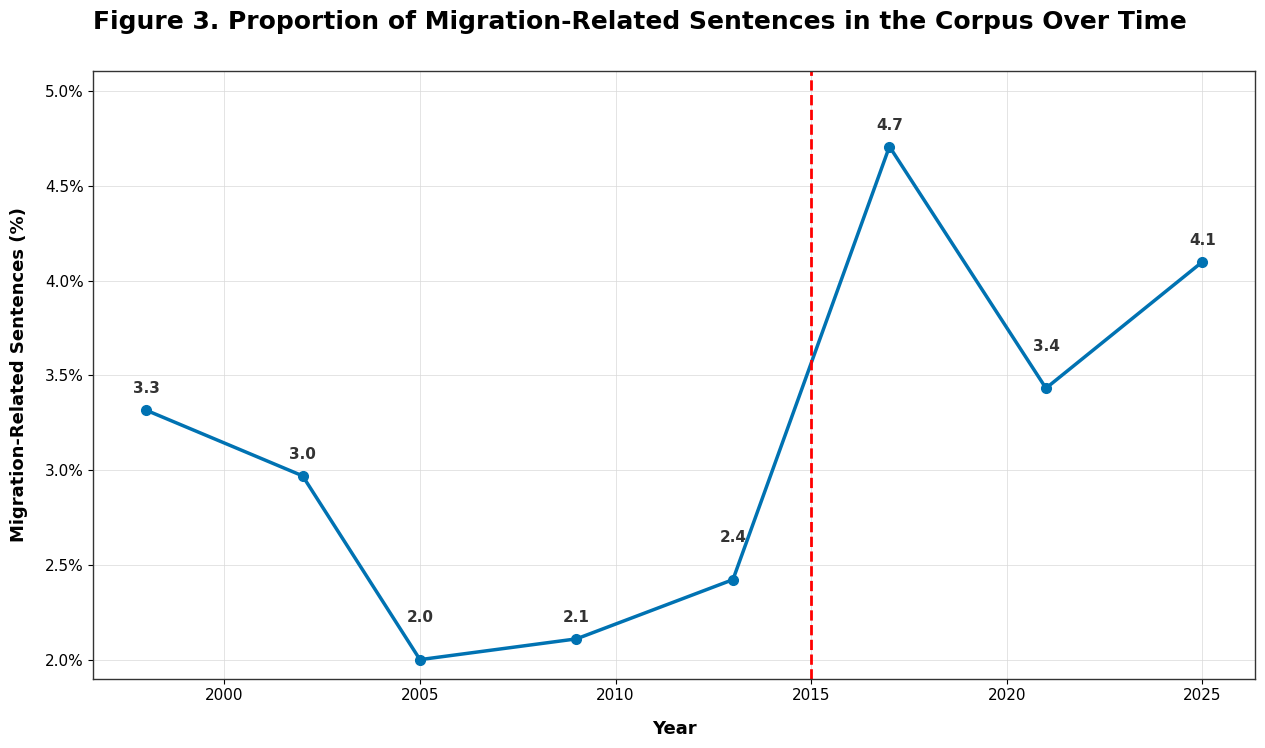

In [ ]:
# this dataset was already cleaned, and more organized than the previous two ones. 
# we used GPT: " We want to create a trend plot for the proportion of migration-related sentences in the corpus over time, 
# and we have a column "gpt_migration" that contains the classification results from GPT, where 1 indicates a migration-related sentence 
# and 0 indicates a non-migration-related sentence.
# we also have a "year" column that contains the year of each sentence.
# we want to calculate the proportion of migration-related sentences for each year, and then plot this trend over time, 
# with the same aesetic elements that we used in figure 1, and as a reference the code of the figure 1 is below,
# and a screenshot of the data is attached, so give us the code to create this trend plot?""

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter


trend_df = (
    df.groupby("year")["gpt_migration"]
    .agg(
        total_sentences="count",
        migration_sentences=lambda x: (x == 1).sum()
    )
    .reset_index()
) # to group the data by year, and then calculate the total number of sentences and the number of migration-related sentences for each year.

trend_df["migration_proportion"] = (
    trend_df["migration_sentences"] / trend_df["total_sentences"]
) # to calculate the proportion of migration-related sentences for each year by dividing the number of migration-related sentences by the total number of sentences for that year.

trend_df["migration_percentage"] = trend_df["migration_proportion"] * 100 # to convert the proportion to percentage by multiplying it by 100.


def percent_format(x, pos):
    return f"{x:.1f}%" # to format the y-axis labels as percentages with one decimal place.


figure_3, ax = plt.subplots(figsize=(14, 8))

figure_3.patch.set_facecolor("white")
ax.set_facecolor("white")

ax.plot(
    trend_df["year"],
    trend_df["migration_percentage"],
    color="#0072B2",
    linewidth=2.5,
    marker="o",
    markersize=7
)

ax.axvline(
    x=2015,
    color="red",
    linestyle="--",
    linewidth=2
) # to add a vertical dashed red line at the year 2015, which is a significant year in the context of migration due to the peak of the European migrant crisis.

ax.set_title(
    "Figure 3. Proportion of Migration-Related Sentences in the Corpus Over Time",
    loc="left",
    fontsize=18,
    color="black",
    weight="bold",
    pad=30
)

ax.set_xlabel("Year", fontsize=13, color="black", labelpad=12)
ax.set_ylabel("Migration-Related Sentences (%)", fontsize=13, color="black", labelpad=12)

ax.tick_params(axis="x", labelsize=11, colors="black")
ax.tick_params(axis="y", labelsize=11, colors="black")

ax.yaxis.set_major_formatter(FuncFormatter(percent_format))

ax.set_ylim(
    trend_df["migration_percentage"].min() - 0.1,
    trend_df["migration_percentage"].max() + 0.4
)


ax.grid(True, linestyle="-", linewidth=0.5, color="#d9d9d9")
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#333333")
    spine.set_linewidth(1)


for x, y in zip(trend_df["year"], trend_df["migration_percentage"]):
    
    if x in [2005, 2013, 2021]:
        offset = 25  d
    else:
        offset = 10

    ax.annotate(
    f"{y:.1f}",
    xy=(x, y),
    xytext=(0, offset),
    textcoords="offset points",
    ha="center",
    va="bottom",
    fontsize=11,
    color="#333333",
    weight="bold"
)
plt.subplots_adjust(
    left=0.15,   
    right=0.92,  
    top=0.85,    
    bottom=0.15  
)

plt.subplots_adjust(left=0.12, right=0.95, top=0.88, bottom=0.12)


figure_3.savefig("figure_3.pdf", bbox_inches="tight", pad_inches=0.3)
figure_3.savefig("figure_3.png", dpi=300, bbox_inches="tight", pad_inches=0.3, facecolor="white")

plt.show()

# Figure 4 Proportion of Migration-Related Sentences by Party Over Time

In [ ]:
# here we wanted to disaggregate the migration and non-migration sentences by party, 
# to see if there are any differences between the parties in terms of the proportion of migration-related sentences.

df["party_id"].unique() # these are the unique values in the "party_id" column, which indicates the different parties in our dataset.

array([41953, 41521, 41113, 41320, 41420, 41730, 41912, 41223, 41221,
       41222, 41952])

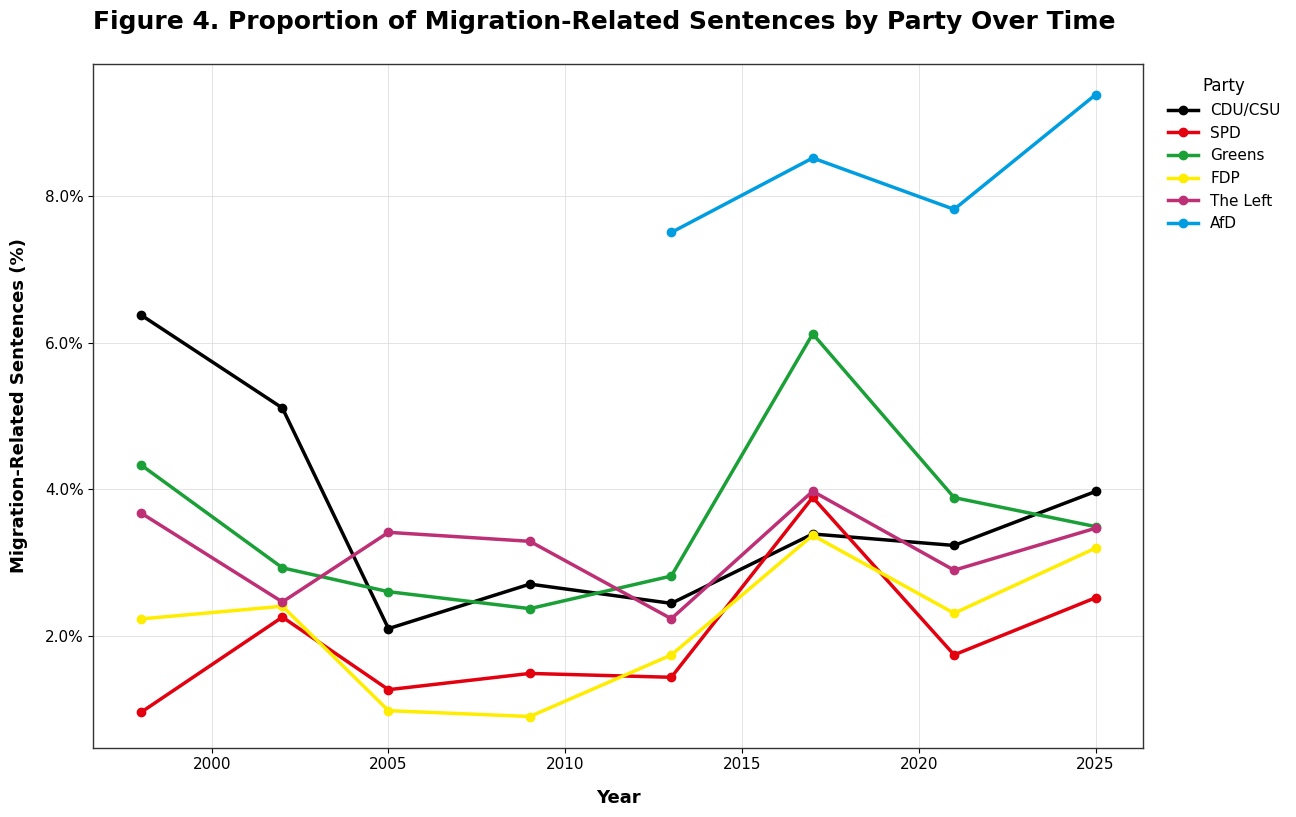

In [ ]:
# This figure we quite easy after creating figure 3(the previous one), we asked GPT the following: 
# "We want now to disaggregate the migration and non-migration sentences by party, 
# to see if there are any differences between the parties in terms of the proportion of migration-related sentences.
# So here is the code of figure 3, how can disaggregate the migration and non-migration sentences by party, and create a similiar plot like the one for figure 3, 
# but this time there is an issue with party_id, since we have only party_id not party names lines for each party,which are
# 41113: "Greens", 41320: "SPD", 41420: "FDP", 41521: "CDU/CSU", 41953: "AfD", 41221: "The Left", 41222: "The Left", 41223: "The Left", so give me now the full code
# considering to record the party_id to the corresponding party names, and to use the same official colors for the parties in the plot, 
# and to use the same aesetic elements that we used in figure 3, and to create a line plot with points for each party, a
# nd to add a legend to differentiate between the parties, and to add the percentage values on top of each point in the plot, 
# and to adjust the y-axis limits to ensure that all percentage values are clearly visible, 
# and to make sure that the plot is visually appealing and easy to read?"



import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter


party_recode = {
    41113: "Greens",
    41320: "SPD",
    41420: "FDP",
    41521: "CDU/CSU",
    41953: "AfD",
    41221: "The Left",
    41222: "The Left",
    41223: "The Left"
} # to recode the party_id values to the corresponding party names, we created a dictionary that maps the party_id values to the party names.

df_plot = df[df["party_id"].isin(party_recode.keys())].copy()

df_plot["party_plot"] = df_plot["party_id"].map(party_recode)


trend_party_df = (
    df_plot.groupby(["year", "party_plot"])["gpt_migration"]
    .agg(
        total_sentences="count",
        migration_sentences=lambda x: (x == 1).sum()
    )
    .reset_index()
)

trend_party_df["migration_percentage"] = (
    trend_party_df["migration_sentences"] / trend_party_df["total_sentences"] * 100
)


party_colors = {
    "CDU/CSU": "#000000",   # black
    "SPD": "#E3000F",       # red
    "Greens": "#1AA037",    # green
    "FDP": "#FFED00",       # yellow
    "The Left": "#BE3075",  # magenta/purple
    "AfD": "#009EE0"        # blue
} # we wanted to use the colors are based on the official party colors in Germany,
# and we can adjust them if needed to ensure they are visually distinct and colorblind-friendly.

party_order = ["CDU/CSU", "SPD", "Greens", "FDP", "The Left", "AfD"]


def percent_format(x, pos):
    return f"{x:.1f}%"


fig, ax = plt.subplots(figsize=(15, 9))

fig.patch.set_facecolor("white")
ax.set_facecolor("white")


for party in party_order:
    party_data = trend_party_df[trend_party_df["party_plot"] == party].sort_values("year")
    
    ax.plot(
        party_data["year"],
        party_data["migration_percentage"],
        label=party,
        color=party_colors[party],
        linewidth=2.5,
        marker="o",
        markersize=6
    )


ax.set_title(
    "Figure 4. Proportion of Migration-Related Sentences by Party Over Time",
    loc="left",
    fontsize=18,
    color="black",
    weight="bold",
    pad=25
)

ax.set_xlabel("Year", fontsize=13, color="black", labelpad=12)
ax.set_ylabel("Migration-Related Sentences (%)", fontsize=13, color="black", labelpad=12)

ax.tick_params(axis="x", labelsize=11, colors="black")
ax.tick_params(axis="y", labelsize=11, colors="black")
ax.yaxis.set_major_formatter(FuncFormatter(percent_format))


ax.grid(True, linestyle="-", linewidth=0.5, color="#d9d9d9")
ax.set_axisbelow(True)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#333333")
    spine.set_linewidth(1)


ax.legend(
    title="Party",
    fontsize=11,
    title_fontsize=12,
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.subplots_adjust(left=0.12, right=0.82, top=0.88, bottom=0.12)


fig.savefig("figure4.pdf", bbox_inches="tight", pad_inches=0.3)
fig.savefig("figure4.png", dpi=300, bbox_inches="tight", pad_inches=0.3, facecolor="white")

plt.show()

In [ ]:
df_migration = pd.read_csv("df_migration.csv") # to read the dataset that contains only the migration-related sentences, 
# which we will use for our figure Appendix 5.

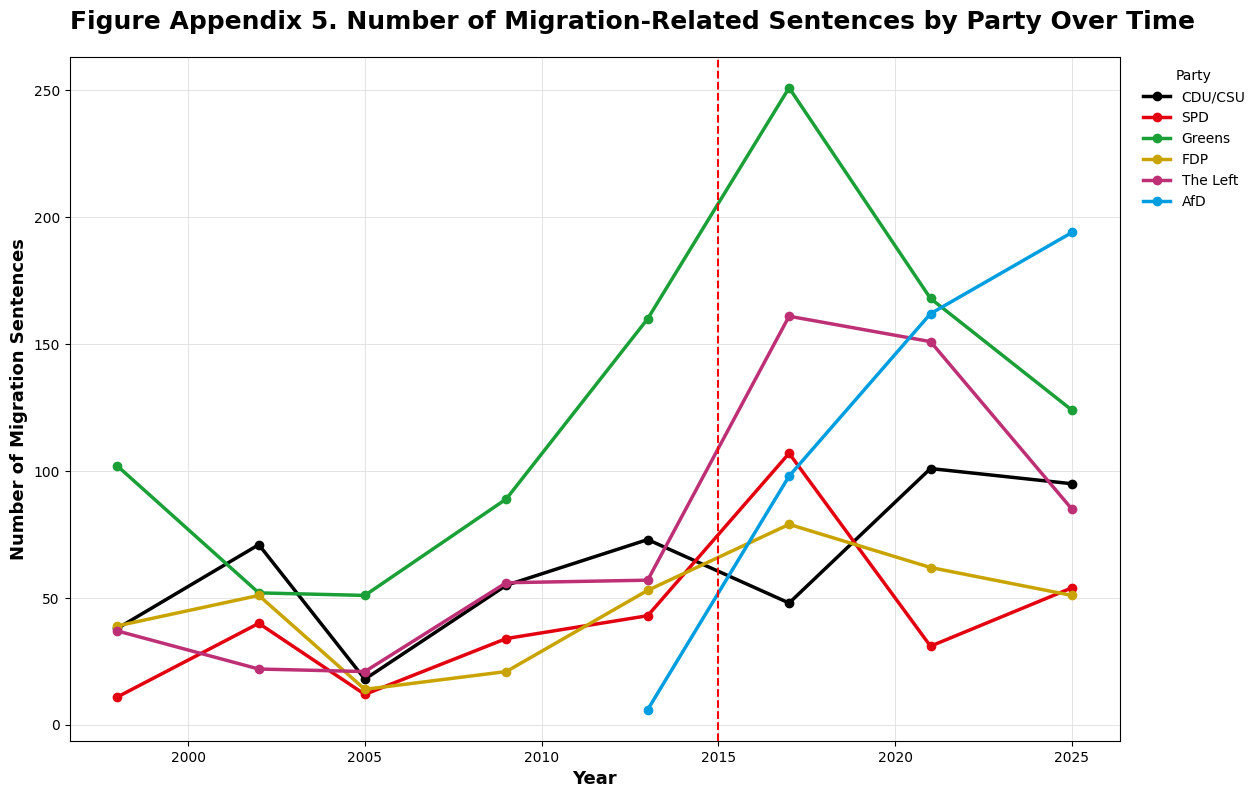

In [ ]:
# here we wanted the same plot as the previous one, but this time we wanted to plot the absolute number of migration-related sentences by party over time. 
# we asked the GPT the following: "We want to create a trend plot for the absolute number of migration-related sentences by party over time, 
# by using the same code figure 4, but our dataset is different, since it contains only the migration-related sentences, so we dont have the "gpt_migration" column. 
# and I want to create a vertical dashed red line at the year 2015. Update the code below, and send the full updated code?"
import pandas as pd
import matplotlib.pyplot as plt


party_recode = {
    41113: "Greens",
    41320: "SPD",
    41420: "FDP",
    41521: "CDU/CSU",
    41953: "AfD",
    41221: "The Left",
    41222: "The Left",
    41223: "The Left"
}

df_mig_plot = df_migration[df_migration["party_id"].isin(party_recode.keys())].copy()
df_mig_plot["party_plot"] = df_mig_plot["party_id"].map(party_recode)


trend_counts = (
    df_mig_plot.groupby(["year", "party_plot"])
    .size()
    .reset_index(name="migration_sentences")
)

party_colors = {
    "CDU/CSU": "#000000",
    "SPD": "#E3000F",
    "Greens": "#1AA037",
    "FDP": "#C9A400",
    "The Left": "#BE3075",
    "AfD": "#009EE0"
}

party_order = ["CDU/CSU", "SPD", "Greens", "FDP", "The Left", "AfD"]

fig, ax = plt.subplots(figsize=(15, 9))

for party in party_order:
    party_data = trend_counts[trend_counts["party_plot"] == party].sort_values("year")
    
    ax.plot(
        party_data["year"],
        party_data["migration_sentences"],
        label=party,
        color=party_colors[party],
        linewidth=2.5,
        marker="o"
    )

ax.axvline(x=2015, color="red", linestyle="--", linewidth=1.5) # to add a vertical dashed red line at the year 2015, which is a significant year in the context of migration due to the peak of the European migrant crisis.

ax.set_title(
    "Figure Appendix 5. Number of Migration-Related Sentences by Party Over Time",
    loc="left",
    fontsize=18,
    weight="bold",
    pad=20
)

ax.set_xlabel("Year", fontsize=13)
ax.set_ylabel("Number of Migration Sentences", fontsize=13)

ax.grid(True, linestyle="-", linewidth=0.5, color="#d9d9d9")

ax.legend(
    title="Party",
    frameon=False,
    bbox_to_anchor=(1.01, 1),
    loc="upper left"
)

plt.subplots_adjust(left=0.12, right=0.82, top=0.88, bottom=0.12)

fig.savefig("figureappendix5.pdf", bbox_inches="tight", pad_inches=0.3)
fig.savefig("figureappendix5.png", dpi=300, bbox_inches="tight", pad_inches=0.3, facecolor="white")


plt.show()

# Summary statistics for appendix 1 (Tables A.1, and A.2) & Some reporting statistics in the methodology section. this section was done without the help of any AI Tools


In [ ]:
import pandas as pd

df = pd.read_csv("df_final_migration_and_non-migration.csv")
print(df.shape)

print(df.columns.tolist()) # to check everything is correct and to see the column names in the dataset.


(106578, 9)
['text', 'text_en', 'cmp_code', 'eu_code', 'party_id', 'year', 'sentence_id', 'cmp_code_clean', 'gpt_migration']


In [ ]:
df["manifesto_id"] = df["party_id"].astype(str) + "_" + df["year"].astype(str) # to create a new column "manifesto_id" that combines the "party_id" and "year

In [ ]:
qs_per_manifesto = df.groupby(["year", "manifesto_id"]).size().reset_index(name="qs_count") # to group the data by year and manifesto_id, and then count the number of sentences for each manifesto in each year, and create a new column "qs_count" to store this count.

print(qs_per_manifesto.head())

   year manifesto_id  qs_count
0  1998   41113_1998      2354
1  1998   41221_1998      1006
2  1998   41320_1998      1143
3  1998   41420_1998      1745
4  1998   41521_1998       596


In [ ]:
# to create a table that shows the number of manifestos fo each election cycle,
# the total number of quasi-sentences, and the average number of quasi-sentences per manifesto for each year, we can use the following code:

table_elections = qs_per_manifesto.groupby("year").agg(
    manifestos=("manifesto_id", "count"),   
    quasi_sentences=("qs_count", "sum"),  
    avg_qs_per_manifesto=("qs_count", "mean")
).round(2)

print(table_elections)

      manifestos  quasi_sentences  avg_qs_per_manifesto
year                                                   
1998           5             6844               1368.80
2002           5             7944               1588.80
2005           5             5793               1158.60
2009           5            12075               2415.00
2013           7            19514               2787.71
2017           6            15810               2635.00
2021           7            20714               2959.14
2025           8            17884               2235.50


In [ ]:
qs_per_manifesto = (
    df.groupby(["year", "manifesto_id"])
    .size()
    .reset_index(name="qs_count")
) # to group the data by year and manifesto_id, and then count the number of sentences for each manifesto in each year, and create a new column "qs_count" to store this count.

In [ ]:
summary_table = (
    qs_per_manifesto.groupby("year")
    .agg(
        manifestos=("manifesto_id", "count"),
        quasi_sentences=("qs_count", "sum"),
        avg_qs_per_manifesto=("qs_count", "mean")
    )
    .round(2)
    .reset_index()
) # to create a summary table that shows the number of manifestos for each election cycle, the total number of quasi-sentences, and the average number of quasi-sentences per manifesto for each year.

In [ ]:
total_qs = qs_per_manifesto["qs_count"].sum()
total_manifestos = qs_per_manifesto["manifesto_id"].nunique()
total_cycles = qs_per_manifesto["year"].nunique()

avg_per_manifesto = total_qs / total_manifestos
avg_per_cycle = total_qs / total_cycles

print("Total quasi-sentences:", total_qs)
print("Total manifestos:", total_manifestos)
print("Election cycles:", total_cycles)
print("Avg per manifesto:", round(avg_per_manifesto, 2))
print("Avg per cycle:", round(avg_per_cycle, 2)) # here to get descriptive statistics about the number of quasi-sentences in our dataset, 
# including the total number of quasi-sentences, the total number of manifestos, the number of election cycles, and the average number of quasi-sentences per manifesto and per election cycle.

Total quasi-sentences: 106578
Total manifestos: 48
Election cycles: 8
Avg per manifesto: 2220.38
Avg per cycle: 13322.25


In [ ]:
distribution = qs_per_manifesto["qs_count"].agg(["mean", "min", "max", "std"]).round(2)
print(distribution) # to get the SD. 

mean    2220.38
min       80.00
max     5675.00
std     1160.93
Name: qs_count, dtype: float64


# After Framing Classification (Roberta and Fine-Tuning)

In [16]:
df_final = pd.read_csv("df_migration_roberta_labeled.csv") # here is our data after framing classification. 

In [ ]:
df_final.info() # to check the data, and ensure that predicted_label is there. 

<class 'pandas.DataFrame'>
RangeIndex: 3495 entries, 0 to 3494
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   text             3495 non-null   str    
 1   text_en          3495 non-null   str    
 2   cmp_code         3410 non-null   str    
 3   eu_code          0 non-null      float64
 4   party_id         3495 non-null   int64  
 5   year             3495 non-null   int64  
 6   sentence_id      3495 non-null   str    
 7   cmp_code_clean   3410 non-null   str    
 8   gpt_migration    3495 non-null   int64  
 9   predicted_label  3495 non-null   str    
dtypes: float64(1), int64(3), str(6)
memory usage: 1.2 MB


In [18]:

# before plotting any figure, we wanted to ensure that we have a colum called party_names. this code is done without any AI support. 

party_names = {
    41113: "Greens",
    41320: "SPD",
    41420: "FDP",
    41521: "CDU/CSU",
    41953: "AfD",
    41221: "The Left",
    41222: "The Left",
    41223: "The Left", 
    41730: "Other",
    41912: "Other", 
    41952: "Other"
}

df_final = df_final[df_final["party_id"].isin(party_names.keys())].copy()

df_final["party_names"] = df_final["party_id"].map(party_names)

df_final["party_names"].unique()

<ArrowStringArray>
['AfD', 'CDU/CSU', 'Greens', 'SPD', 'FDP', 'Other', 'The Left']
Length: 7, dtype: str

In [ ]:
df_final.info() # to check that our new colum "party_names" is there. 

<class 'pandas.DataFrame'>
RangeIndex: 3495 entries, 0 to 3494
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   text             3495 non-null   str    
 1   text_en          3495 non-null   str    
 2   cmp_code         3410 non-null   str    
 3   eu_code          0 non-null      float64
 4   party_id         3495 non-null   int64  
 5   year             3495 non-null   int64  
 6   sentence_id      3495 non-null   str    
 7   cmp_code_clean   3410 non-null   str    
 8   gpt_migration    3495 non-null   int64  
 9   predicted_label  3495 non-null   str    
 10  party_names      3495 non-null   str    
dtypes: float64(1), int64(3), str(7)
memory usage: 1.3 MB


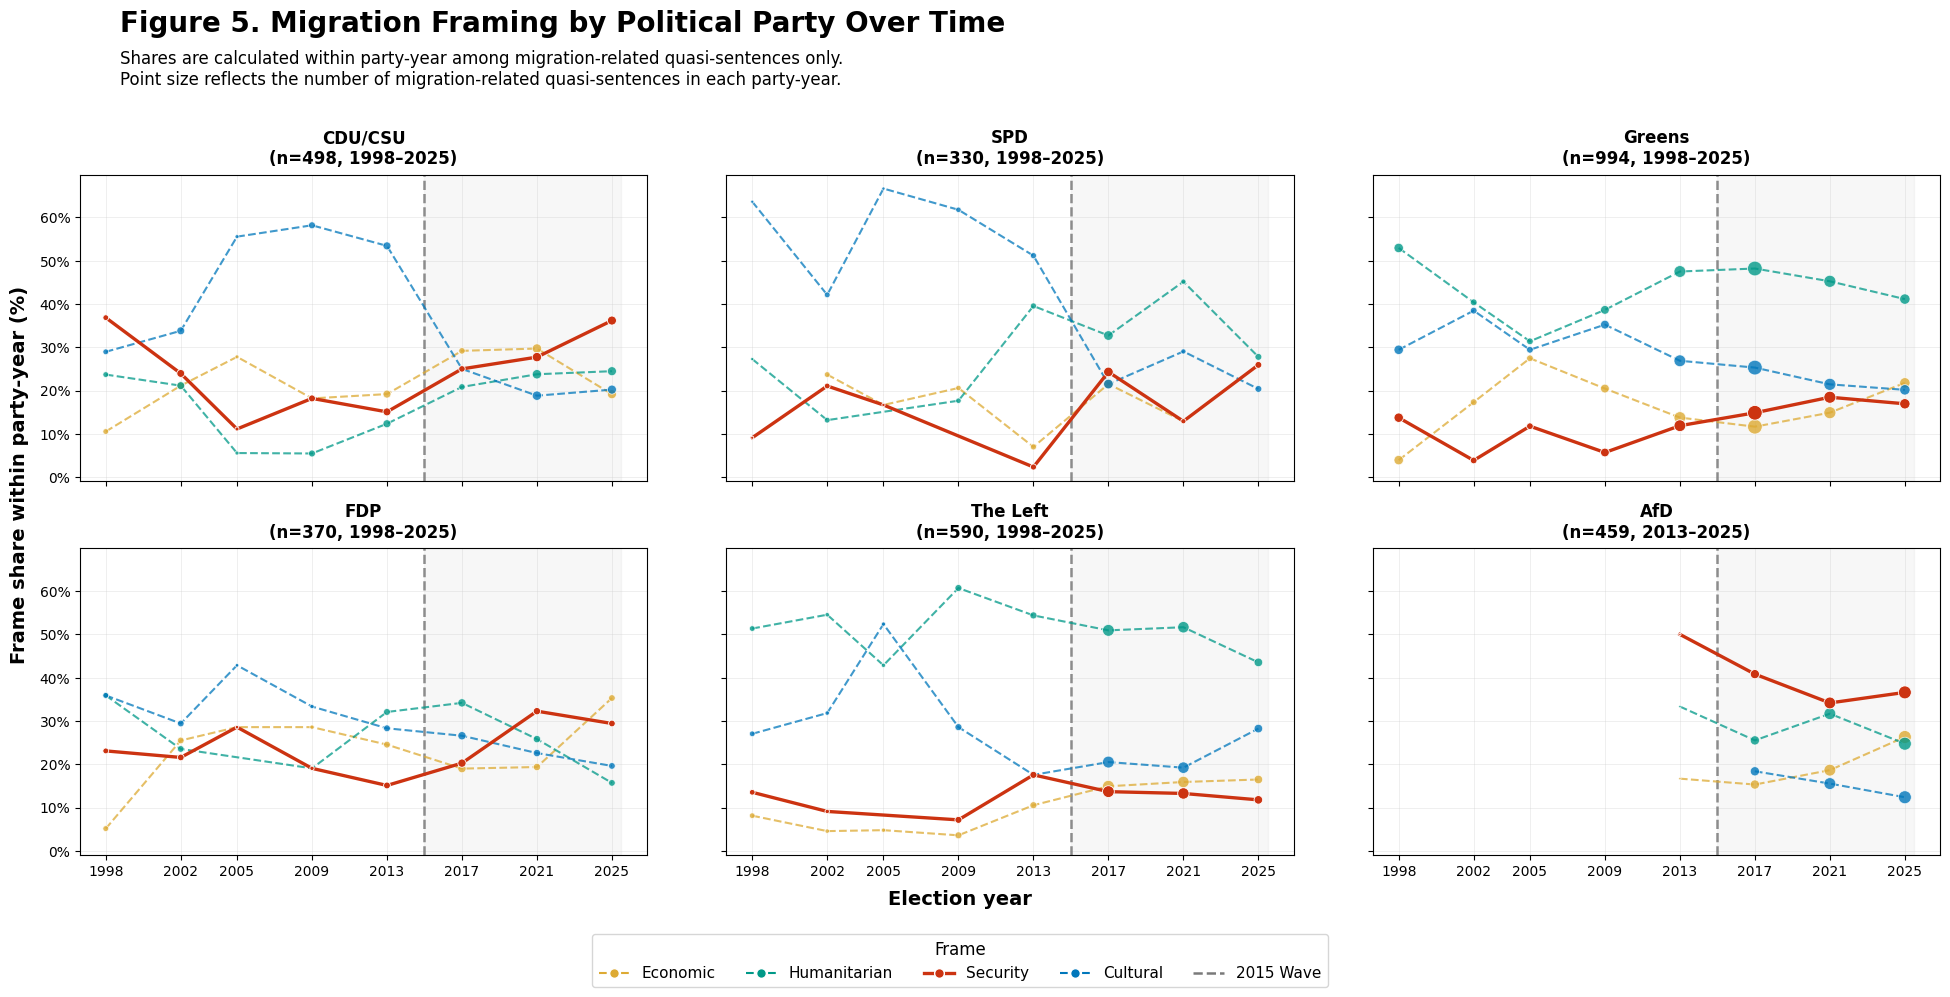

In [21]:
# We used claude this time to create this code: the prompt: 
# "Attached is a screenshot of our dataset, we wanted to create a trend plot for the proportion of different frames (economic, humanitarian, security, cultural)
# by party over time for the big six parties (CDU/CSU, SPD, Greens, FDP, The Left, AfD), using subplot for each party, we need to have a dashline of 2015, 
# and there should a different of color before and after 2015, 
# and because the security frame is of particular interest, we want to highlight more than as frames,add the legend, and add the total number of sentences 
# for each party across all years and the time frame (years) in the title of each subplot, 
# and to make sure that the plot is visually appealing and easy to read, so give us the full code to create this figure?"


import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D


mpl.rcdefaults()
mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.style": "normal",
    "font.weight": "normal",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "text.usetex": False
})


big_parties = ["CDU/CSU", "SPD", "Greens", "FDP", "The Left", "AfD"]
frame_order = ["economic", "humanitarian", "security", "cultural"]

frame_colors = {
    "economic": "#DDAA33",
    "humanitarian": "#009988",
    "security": "#CC3311",
    "cultural": "#0077BB"
}

EMPHASIZE_FRAME = "security"  
SHOW_CI = False
SAVE_FIGURES = False
marker_2015_color = "#7A7A7A"


df_plot = df_final[
    (df_final["party_names"].isin(big_parties)) &
    (df_final["predicted_label"].isin(frame_order))
].copy()


frame_trend = (
    df_plot.groupby(["year", "party_names", "predicted_label"])
    .size()
    .reset_index(name="count")
)

party_year_totals = (
    frame_trend.groupby(["year", "party_names"])["count"]
    .sum()
    .reset_index(name="total_n")
)

frame_trend = frame_trend.merge(
    party_year_totals,
    on=["year", "party_names"],
    how="left"
)

frame_trend["share"] = frame_trend["count"] / frame_trend["total_n"] * 100

frame_trend["se"] = np.sqrt(
    (frame_trend["share"] / 100) * (1 - frame_trend["share"] / 100) / frame_trend["total_n"]
) * 100

frame_trend["party_names"] = pd.Categorical(
    frame_trend["party_names"],
    categories=big_parties,
    ordered=True
)
frame_trend["predicted_label"] = pd.Categorical(
    frame_trend["predicted_label"],
    categories=frame_order,
    ordered=True
)

frame_trend = frame_trend.sort_values(["party_names", "predicted_label", "year"])


fig, axes = plt.subplots(2, 3, figsize=(20, 10), sharex=True, sharey=True)
axes = axes.flatten()

all_years = sorted(frame_trend["year"].unique())

for i, party in enumerate(big_parties):
    ax = axes[i]
    party_data = frame_trend[frame_trend["party_names"] == party].copy()

    total_party_n = int(party_data["count"].sum())
    years_present = sorted(party_data["year"].unique())
    year_range = f"{min(years_present)}–{max(years_present)}"

    ax.axvspan(2015, max(all_years) + 0.5, alpha=0.06, color="gray", zorder=0)

    ax.axvline(
        x=2015,
        color=marker_2015_color,
        linestyle="--",
        linewidth=1.8,
        alpha=0.85,
        zorder=1
    )

    for frame in frame_order:
        data = party_data[party_data["predicted_label"] == frame].sort_values("year").copy()

        if data.empty:
            continue

        if EMPHASIZE_FRAME is not None and frame == EMPHASIZE_FRAME:
            linestyle = "-"
            linewidth = 2.4
            alpha_line = 1.0
            alpha_point = 1.0
            zorder = 10
        elif EMPHASIZE_FRAME is not None:
            linestyle = "--"
            linewidth = 1.5
            alpha_line = 0.75
            alpha_point = 0.8
            zorder = 5
        else:
            linestyle = "--"
            linewidth = 1.6
            alpha_line = 0.9
            alpha_point = 0.9
            zorder = 5

        ax.plot(
            data["year"],
            data["share"],
            linestyle=linestyle,
            linewidth=linewidth,
            alpha=alpha_line,
            color=frame_colors[frame],
            zorder=zorder
        )

        ax.scatter(
            data["year"],
            data["share"],
            s=data["total_n"] * 0.45,
            color=frame_colors[frame],
            alpha=alpha_point,
            edgecolors="white",
            linewidths=0.6,
            zorder=zorder + 1
        )

        if SHOW_CI and EMPHASIZE_FRAME is not None and frame == EMPHASIZE_FRAME:
            lower = np.maximum(0, data["share"] - 1.96 * data["se"])
            upper = np.minimum(100, data["share"] + 1.96 * data["se"])
            ax.fill_between(
                data["year"],
                lower,
                upper,
                color=frame_colors[frame],
                alpha=0.18,
                zorder=zorder - 1
            )

    ax.set_title(
        f"{party}\n(n={total_party_n}, {year_range})",
        fontsize=12,
        weight="bold",
        pad=8
    )

    ax.grid(True, alpha=0.4, linestyle="-", linewidth=0.6, color="#D0D0D0")
    ax.set_axisbelow(True)

    ax.set_xticks(all_years)
    ax.set_xticklabels([str(y) for y in all_years], rotation=0, fontsize=10)

    for label in ax.get_xticklabels():
        label.set_fontstyle("normal")
        label.set_fontweight("normal")
        label.set_family("DejaVu Sans")

    ax.tick_params(axis="y", labelsize=10)
    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x:.0f}%"))


fig.text(0.5, 0.07, "Election year", ha="center", fontsize=14, weight="bold")
fig.text(
    0.025, 0.5,
    "Frame share within party-year (%)",
    va="center",
    rotation="vertical",
    fontsize=14,
    weight="bold"
)

left_anchor = 0.08

fig.text(
    left_anchor, 0.965,
    "Figure 5. Migration Framing by Political Party Over Time",
    ha="left",
    va="top",
    fontsize=20,
    weight="bold"
)

fig.text(
    left_anchor, 0.925,
    "Shares are calculated within party-year among migration-related quasi-sentences only.\n"
    "Point size reflects the number of migration-related quasi-sentences in each party-year.",
    ha="left",
    va="top",
    fontsize=12,
    color="black"
)

legend_handles = [
    Line2D([0], [0],
           color=frame_colors[frame],
           lw=2.4 if frame == EMPHASIZE_FRAME else 1.5,
           linestyle="-" if frame == EMPHASIZE_FRAME else "--",
           marker="o",
           markersize=7,
           markerfacecolor=frame_colors[frame],
           markeredgecolor="white",
           label=frame.title())
    for frame in frame_order
]

legend_handles.append(
    Line2D([0], [0],
           color=marker_2015_color,
           lw=1.8,
           linestyle="--",
           label="2015 Wave")
)

fig.legend(
    handles=legend_handles,
    title="Frame",
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.02),
    frameon=True,
    fontsize=11,
    title_fontsize=12
)



plt.subplots_adjust(
    left=0.06,
    right=0.99,
    bottom=0.12,
    top=0.80,
    wspace=0.14,
    hspace=0.22
)
fig.savefig(
        "figure5.png",
        bbox_inches="tight",
        pad_inches=0.3,
        dpi=300
    )
fig.savefig(
        "figure5.pdf",
        bbox_inches="tight",
        pad_inches=0.3,
        dpi=300
    )
plt.show()

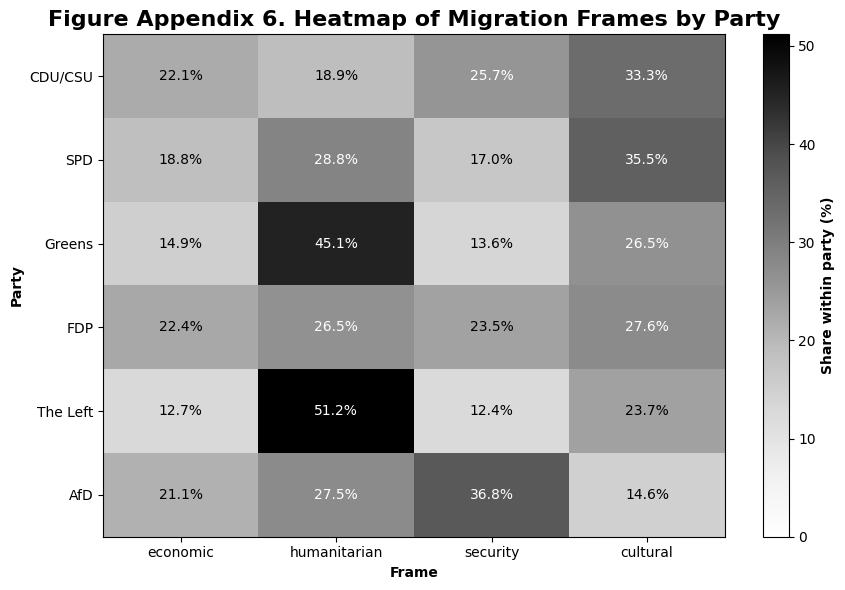

In [22]:

# For this code, we used GPT. the current prompt was used: "I wanna now create a heatmap. Just modeify the code below to create a heatmap 
# that shows the share of each migration frame (economic, humanitarian, security, cultural) 
# within each party-year among migration-related quasi-sentences only, for the big six parties (CDU/CSU, SPD, Greens, FDP, The Left, AfD). 
# the heatmap should be in grey scale, with darker shades indicating higher shares."  
# We provided GPT here with the code of figure 5. 


import pandas as pd
import matplotlib.pyplot as plt

big_parties = ["CDU/CSU", "SPD", "Greens", "FDP", "The Left", "AfD"]
frame_order = ["economic", "humanitarian", "security", "cultural"]

df_heat = df_final[
    (df_final["party_names"].isin(big_parties)) &
    (df_final["predicted_label"].isin(frame_order))
].copy()


party_frame_counts = (
    df_heat.groupby(["party_names", "predicted_label"])
    .size()
    .reset_index(name="count")
)


party_totals = party_frame_counts.groupby("party_names")["count"].transform("sum")
party_frame_counts["share"] = party_frame_counts["count"] / party_totals * 100


heatmap_data = party_frame_counts.pivot(
    index="party_names",
    columns="predicted_label",
    values="share"
).fillna(0)

party_order = ["CDU/CSU", "SPD", "Greens", "FDP", "The Left", "AfD"]
heatmap_data = heatmap_data.reindex(index=party_order, columns=frame_order)

fig, ax = plt.subplots(figsize=(9, 6))

im = ax.imshow(
    heatmap_data,
    aspect="auto",
    cmap="Greys",
    vmin=0,
    vmax=heatmap_data.values.max()
)

ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=0)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

ax.set_title("Figure Appendix 6. Heatmap of Migration Frames by Party", fontsize=16, weight="bold")
ax.set_xlabel("Frame")
ax.set_ylabel("Party")


max_val = heatmap_data.values.max()

for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        value = heatmap_data.iloc[i, j]

        text_color = "white" if value > max_val * 0.5 else "black"

        ax.text(
            j,
            i,
            f"{value:.1f}%",
            ha="center",
            va="center",
            fontsize=10,
            color=text_color
        )

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Share within party (%)")

plt.tight_layout()

fig.savefig("figure_appendix_6.pdf", bbox_inches="tight", pad_inches=0.3)
fig.savefig("figure_appendix_6.png", dpi=300, bbox_inches="tight", pad_inches=0.3)

plt.show()

# We run binary logistic regression analysis as our robust check. All these plots were presented in our appendices. 


Number of manifesto clusters: 44

MODEL A: SECURITY vs OTHER FRAMES | WITHOUT AfD | CLUSTERED BY MANIFESTO
                           Logit Regression Results                           
Dep. Variable:        security_binary   No. Observations:                 2782
Model:                          Logit   Df Residuals:                     2776
Method:                           MLE   Df Model:                            5
Date:                Fri, 01 May 2026   Pseudo R-squ.:                 0.02526
Time:                        16:14:25   Log-Likelihood:                -1245.6
converged:                       True   LL-Null:                       -1277.8
Covariance Type:              cluster   LLR p-value:                 1.380e-12
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.0372      0.128     -8.093      0.000      -1.288      -0.786
SPD            

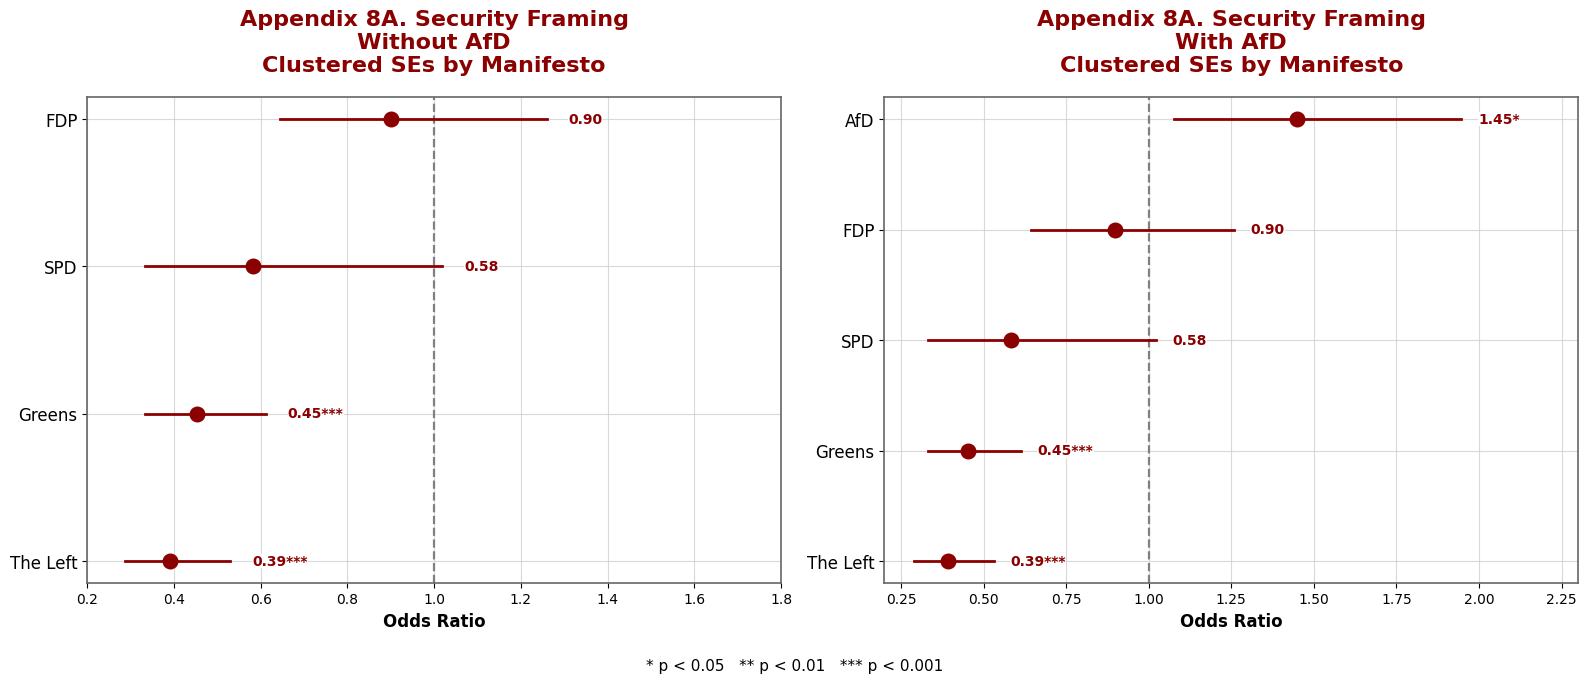

In [23]:
# Since we wanted to run a logistic regression model to analyze the relationship between the predicted migration frame (security vs. other frames) 
# and the political party, while controlling for the year and clustering standard errors at the manifesto level, we asked chatGPT the following:
#  "We want to run a logistic regression model to analyze the relationship between the predicted migration frame (security vs. other frames) 
# and the political party, while controlling for the year and clustering standard errors at the manifesto level, and the CDU/CSU is our reference letter.
# Because the AfD was established in 2013, we want to run two models, one with the AfD and one without the AfD, 
# and we want to compare the results of the two models. After doing that, we want to extract the odds ratios and 
# confidence intervals for the party coefficients from both models, and create a table that summarizes these results, including the significance levels."


# After we got the code, we played a bit around the title of plot, font, the colors, and the other aesthetics of the plot. So GPT give us the main code,
# and then we modified it a bit to make it more visually appealing.

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


df = df_final.copy()

keep_parties = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP", "AfD"]
df["party_names"] = df["party_names"].astype(str).str.strip()
df = df[df["party_names"].isin(keep_parties)].copy()

df["predicted_label"] = (
    df["predicted_label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

label_map = {
    "humanitarian": "humanitarian",
    "economic": "economic",
    "security": "security",
    "securitroy": "security",
    "cultural": "cultural",
    "culturee": "cultural"
}
df["predicted_label"] = df["predicted_label"].replace(label_map)

valid_labels = ["humanitarian", "economic", "security", "cultural"]
df = df[df["predicted_label"].isin(valid_labels)].copy()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)

df["security_binary"] = (df["predicted_label"] == "security").astype(int)

df["year_centered"] = df["year"] - df["year"].mean()


df["manifesto_id"] = df["sentence_id"].astype(str).str.rsplit("_", n=1).str[0]

print("Number of manifesto clusters:", df["manifesto_id"].nunique())


def run_logit_manifesto_cluster(data, party_order, model_name):
    data = data.copy()

    data["party_names"] = pd.Categorical(
        data["party_names"],
        categories=party_order,
        ordered=True
    )

    X = pd.get_dummies(data["party_names"], drop_first=True, dtype=float)
    X["year_centered"] = data["year_centered"].astype(float)
    X = sm.add_constant(X, has_constant="add")

    y = data["security_binary"].astype(int)
    groups = data["manifesto_id"]

    model = sm.Logit(y, X)

    result = model.fit(
        disp=False,
        cov_type="cluster",
        cov_kwds={"groups": groups}
    )

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(result.summary())

    return result


df_no_afd = df[df["party_names"] != "AfD"].copy()

party_order_no_afd = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP"]

result_no_afd = run_logit_manifesto_cluster(
    data=df_no_afd,
    party_order=party_order_no_afd,
    model_name="MODEL A: SECURITY vs OTHER FRAMES | WITHOUT AfD | CLUSTERED BY MANIFESTO"
)


df_with_afd = df.copy()

party_order_with_afd = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP", "AfD"]

result_with_afd = run_logit_manifesto_cluster(
    data=df_with_afd,
    party_order=party_order_with_afd,
    model_name="MODEL B: SECURITY vs OTHER FRAMES | WITH AfD | CLUSTERED BY MANIFESTO"
)


def extract_or_ci(logit_result, terms_to_keep):
    params = logit_result.params.copy()
    conf = logit_result.conf_int().copy()
    pvals = logit_result.pvalues.copy()

    lower_col = conf.columns[0]
    upper_col = conf.columns[1]

    out = pd.DataFrame({
        "term": params.index,
        "coef": params.values,
        "lower_coef": conf[lower_col].values,
        "upper_coef": conf[upper_col].values,
        "pval": pvals.values
    })

    out = out[out["term"].isin(terms_to_keep)].copy()

    out["odds_ratio"] = np.exp(out["coef"])
    out["lower"] = np.exp(out["lower_coef"])
    out["upper"] = np.exp(out["upper_coef"])

    def stars(p):
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return ""

    out["stars"] = out["pval"].apply(stars)
    return out

terms_no_afd = ["SPD", "Greens", "The Left", "FDP"]
terms_with_afd = ["SPD", "Greens", "The Left", "FDP", "AfD"]

or_no_afd = extract_or_ci(result_no_afd, terms_no_afd)
or_with_afd = extract_or_ci(result_with_afd, terms_with_afd)

print("\nOdds Ratios - Model A (without AfD)")
print(or_no_afd[["term", "odds_ratio", "lower", "upper", "pval", "stars"]])

print("\nOdds Ratios - Model B (with AfD)")
print(or_with_afd[["term", "odds_ratio", "lower", "upper", "pval", "stars"]])

plot_order_no_afd = ["FDP", "SPD", "Greens", "The Left"]
plot_order_with_afd = ["AfD", "FDP", "SPD", "Greens", "The Left"]

or_no_afd["term"] = pd.Categorical(or_no_afd["term"], categories=plot_order_no_afd, ordered=True)
or_no_afd = or_no_afd.sort_values("term").reset_index(drop=True)

or_with_afd["term"] = pd.Categorical(or_with_afd["term"], categories=plot_order_with_afd, ordered=True)
or_with_afd = or_with_afd.sort_values("term").reset_index(drop=True)


def forest_plot(ax, df_or, title, color, x_min=None, x_max=None):
    y = np.arange(len(df_or))

    ax.set_facecolor("white")
    ax.grid(True, axis="both", linestyle="-", linewidth=0.8, color="#d0d0d0", alpha=0.8)
    ax.set_axisbelow(True)

    for i, row in enumerate(df_or.itertuples()):
        ax.plot([row.lower, row.upper], [i, i], color=color, linewidth=2.0, zorder=2)

    ax.scatter(df_or["odds_ratio"], y, color=color, s=110, zorder=3)
    ax.axvline(1, color="gray", linestyle="--", linewidth=1.6, zorder=1)

    ax.set_yticks(y)
    ax.set_yticklabels(df_or["term"], fontsize=12)
    ax.set_xlabel("Odds Ratio", fontsize=12, weight="bold")
    ax.set_title(title, fontsize=16, weight="bold", color=color, pad=18)

    ax.invert_yaxis()

    if x_min is None:
        x_min = max(0, df_or["lower"].min() - 0.15)
    if x_max is None:
        x_max = df_or["upper"].max() + 0.4

    ax.set_xlim(x_min, x_max)

    for i, row in enumerate(df_or.itertuples()):
        label = f"{row.odds_ratio:.2f}{row.stars}"
        x_left, x_right = ax.get_xlim()

        if row.odds_ratio > x_right * 0.75:
            x_text = row.odds_ratio - 0.15
            ha = "right"
        else:
            x_text = min(row.upper + 0.05, x_right - 0.10)
            ha = "left"

        ax.text(
            x_text,
            i,
            label,
            va="center",
            ha=ha,
            fontsize=10,
            color=color,
            weight="bold",
            bbox=dict(facecolor="white", edgecolor="none", pad=0.2)
        )

    for spine in ax.spines.values():
        spine.set_color("#666666")
        spine.set_linewidth(1.2)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("white")

forest_plot(
    axes[0],
    or_no_afd,
    "Appendix 8A. Security Framing\nWithout AfD\nClustered SEs by Manifesto",
    color="darkred",
    x_min=0.2,
    x_max=max(or_no_afd["upper"].max() + 0.3, 1.8)
)

forest_plot(
    axes[1],
    or_with_afd,
    "Appendix 8A. Security Framing\nWith AfD\nClustered SEs by Manifesto",
    color="darkred",
    x_min=0.2,
    x_max=max(or_with_afd["upper"].max() + 0.3, 2.3)
)

fig.text(
    0.5,
    0.04,
    "* p < 0.05   ** p < 0.01   *** p < 0.001",
    ha="center",
    va="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.07, 1, 1])

plt.savefig("appendix8_security.png", dpi=300, bbox_inches="tight")
plt.savefig("appendix8_security.pdf", dpi=300, bbox_inches="tight")
plt.show()

Number of manifesto clusters: 44

MODEL A: HUMANITARIAN vs OTHER FRAMES | WITHOUT AfD | CLUSTERED BY MANIFESTO
                            Logit Regression Results                           
Dep. Variable:     humanitarian_binary   No. Observations:                 2782
Model:                           Logit   Df Residuals:                     2776
Method:                            MLE   Df Model:                            5
Date:                 Sat, 25 Apr 2026   Pseudo R-squ.:                 0.04964
Time:                         19:52:30   Log-Likelihood:                -1746.0
converged:                        True   LL-Null:                       -1837.2
Covariance Type:               cluster   LLR p-value:                 1.634e-37
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.4547      0.155     -9.391      0.000      -1.758      -1.151
SPD

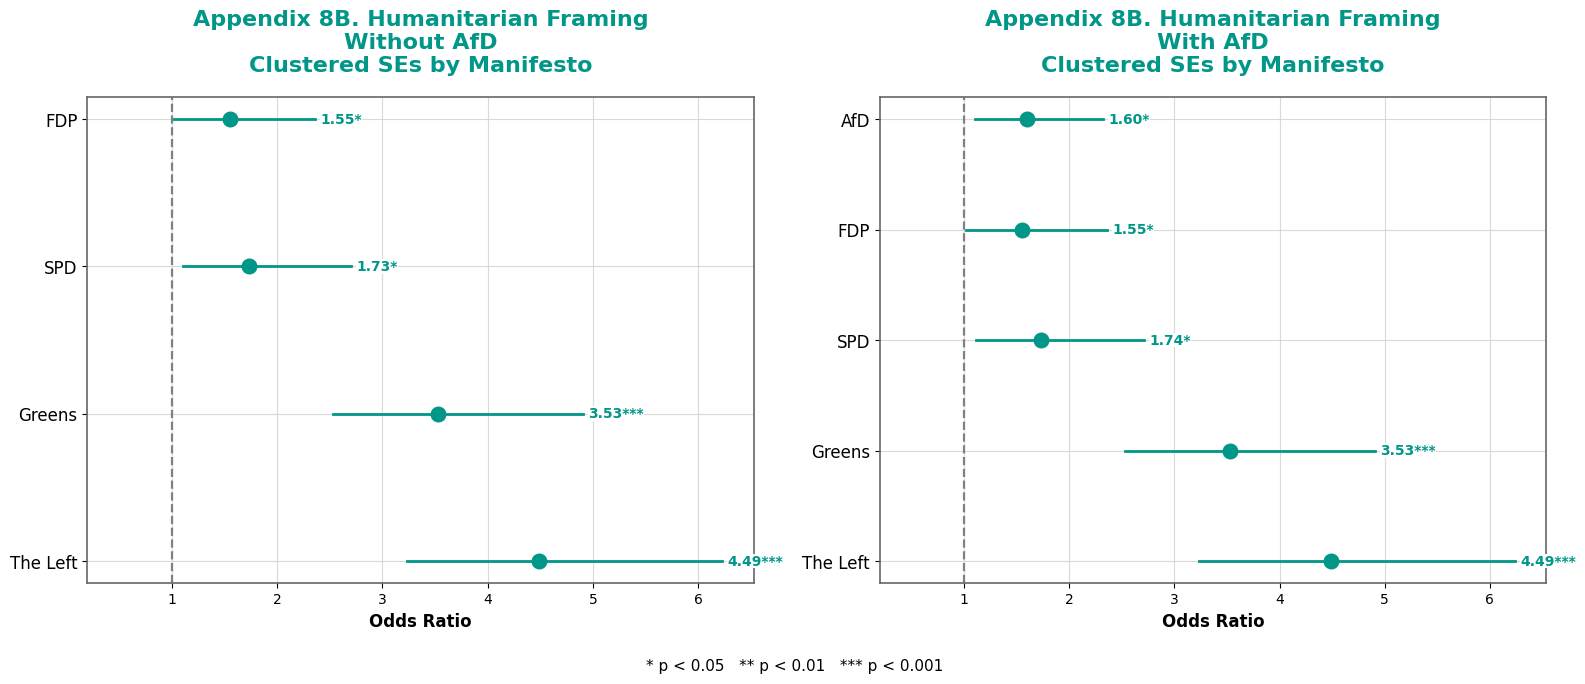

In [ ]:
# We used here the same code from the previous one; 
# but we changed only the frame, the title, and the color to create the same plot for the humanitarian frame.


import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

df = df_final.copy()

keep_parties = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP", "AfD"]

df["party_names"] = df["party_names"].astype(str).str.strip()
df = df[df["party_names"].isin(keep_parties)].copy()

df["predicted_label"] = (
    df["predicted_label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

label_map = {
    "humanitarian": "humanitarian",
    "economic": "economic",
    "security": "security",
    "securitroy": "security",
    "cultural": "cultural",
    "culturee": "cultural"
}

df["predicted_label"] = df["predicted_label"].replace(label_map)

valid_labels = ["humanitarian", "economic", "security", "cultural"]
df = df[df["predicted_label"].isin(valid_labels)].copy()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)


df["humanitarian_binary"] = (df["predicted_label"] == "humanitarian").astype(int)

df["year_centered"] = df["year"] - df["year"].mean()


df["manifesto_id"] = df["sentence_id"].astype(str).str.rsplit("_", n=1).str[0]

print("Number of manifesto clusters:", df["manifesto_id"].nunique())

def run_logit_manifesto_cluster(data, party_order, model_name):
    data = data.copy()

    data["party_names"] = pd.Categorical(
        data["party_names"],
        categories=party_order,
        ordered=True
    )

    X = pd.get_dummies(data["party_names"], drop_first=True, dtype=float)
    X["year_centered"] = data["year_centered"].astype(float)
    X = sm.add_constant(X, has_constant="add")

    y = data["humanitarian_binary"].astype(int)
    groups = data["manifesto_id"]

    model = sm.Logit(y, X)

    result = model.fit(
        disp=False,
        cov_type="cluster",
        cov_kwds={"groups": groups}
    )

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(result.summary())

    return result


df_no_afd = df[df["party_names"] != "AfD"].copy()

party_order_no_afd = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP"]

result_no_afd = run_logit_manifesto_cluster(
    data=df_no_afd,
    party_order=party_order_no_afd,
    model_name="MODEL A: HUMANITARIAN vs OTHER FRAMES | WITHOUT AfD | CLUSTERED BY MANIFESTO"
)


df_with_afd = df.copy()

party_order_with_afd = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP", "AfD"]

result_with_afd = run_logit_manifesto_cluster(
    data=df_with_afd,
    party_order=party_order_with_afd,
    model_name="MODEL B: HUMANITARIAN vs OTHER FRAMES | WITH AfD | CLUSTERED BY MANIFESTO"
)

def extract_or_ci(logit_result, terms_to_keep):
    params = logit_result.params.copy()
    conf = logit_result.conf_int().copy()
    pvals = logit_result.pvalues.copy()

    lower_col = conf.columns[0]
    upper_col = conf.columns[1]

    out = pd.DataFrame({
        "term": params.index,
        "coef": params.values,
        "lower_coef": conf[lower_col].values,
        "upper_coef": conf[upper_col].values,
        "pval": pvals.values
    })

    out = out[out["term"].isin(terms_to_keep)].copy()

    out["odds_ratio"] = np.exp(out["coef"])
    out["lower"] = np.exp(out["lower_coef"])
    out["upper"] = np.exp(out["upper_coef"])

    def stars(p):
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return ""

    out["stars"] = out["pval"].apply(stars)

    return out

terms_no_afd = ["SPD", "Greens", "The Left", "FDP"]
terms_with_afd = ["SPD", "Greens", "The Left", "FDP", "AfD"]

or_no_afd = extract_or_ci(result_no_afd, terms_no_afd)
or_with_afd = extract_or_ci(result_with_afd, terms_with_afd)

print("\nOdds Ratios - Model A (without AfD)")
print(or_no_afd[["term", "odds_ratio", "lower", "upper", "pval", "stars"]])

print("\nOdds Ratios - Model B (with AfD)")
print(or_with_afd[["term", "odds_ratio", "lower", "upper", "pval", "stars"]])


plot_order_no_afd = ["FDP", "SPD", "Greens", "The Left"]
plot_order_with_afd = ["AfD", "FDP", "SPD", "Greens", "The Left"]

or_no_afd["term"] = pd.Categorical(
    or_no_afd["term"],
    categories=plot_order_no_afd,
    ordered=True
)
or_no_afd = or_no_afd.sort_values("term").reset_index(drop=True)

or_with_afd["term"] = pd.Categorical(
    or_with_afd["term"],
    categories=plot_order_with_afd,
    ordered=True
)
or_with_afd = or_with_afd.sort_values("term").reset_index(drop=True)

def forest_plot(ax, df_or, title, color, x_min=None, x_max=None):
    y = np.arange(len(df_or))

    ax.set_facecolor("white")
    ax.grid(True, axis="both", linestyle="-", linewidth=0.8, color="#d0d0d0", alpha=0.8)
    ax.set_axisbelow(True)

    for i, row in enumerate(df_or.itertuples()):
        ax.plot(
            [row.lower, row.upper],
            [i, i],
            color=color,
            linewidth=2.0,
            zorder=2
        )

    ax.scatter(df_or["odds_ratio"], y, color=color, s=110, zorder=3)
    ax.axvline(1, color="gray", linestyle="--", linewidth=1.6, zorder=1)

    ax.set_yticks(y)
    ax.set_yticklabels(df_or["term"], fontsize=12)
    ax.set_xlabel("Odds Ratio", fontsize=12, weight="bold")
    ax.set_title(title, fontsize=16, weight="bold", color=color, pad=18)

    ax.invert_yaxis()

    if x_min is None:
        x_min = max(0, df_or["lower"].min() - 0.15)
    if x_max is None:
        x_max = df_or["upper"].max() + 0.4

    ax.set_xlim(x_min, x_max)

    for i, row in enumerate(df_or.itertuples()):
        label = f"{row.odds_ratio:.2f}{row.stars}"
        x_left, x_right = ax.get_xlim()

        if row.odds_ratio > x_right * 0.75:
            x_text = row.odds_ratio - 0.15
            ha = "right"
        else:
            x_text = min(row.upper + 0.05, x_right - 0.10)
            ha = "left"

        ax.text(
            x_text,
            i,
            label,
            va="center",
            ha=ha,
            fontsize=10,
            color=color,
            weight="bold",
            bbox=dict(facecolor="white", edgecolor="none", pad=0.2)
        )

    for spine in ax.spines.values():
        spine.set_color("#666666")
        spine.set_linewidth(1.2)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("white")

forest_plot(
    axes[0],
    or_no_afd,
    "Appendix 8B. Humanitarian Framing\nWithout AfD\nClustered SEs by Manifesto",
    color="#009688",
    x_min=0.2,
    x_max=max(or_no_afd["upper"].max() + 0.3, 1.8)
)

forest_plot(
    axes[1],
    or_with_afd,
    "Appendix 8B. Humanitarian Framing\nWith AfD\nClustered SEs by Manifesto",
    color="#009688",
    x_min=0.2,
    x_max=max(or_with_afd["upper"].max() + 0.3, 2.3)
)

fig.text(
    0.5,
    0.04,
    "* p < 0.05   ** p < 0.01   *** p < 0.001",
    ha="center",
    va="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.07, 1, 1])

plt.savefig("appendix8_human.png", dpi=300, bbox_inches="tight")
plt.savefig("appendix8_human.pdf", dpi=300, bbox_inches="tight")
plt.show()

Number of manifesto clusters: 44

MODEL A: ECONOMIC vs OTHER FRAMES | WITHOUT AfD | CLUSTERED BY MANIFESTO
                           Logit Regression Results                           
Dep. Variable:        economic_binary   No. Observations:                 2782
Model:                          Logit   Df Residuals:                     2776
Method:                           MLE   Df Model:                            5
Date:                Sat, 25 Apr 2026   Pseudo R-squ.:                 0.01666
Time:                        19:52:51   Log-Likelihood:                -1255.0
converged:                       True   LL-Null:                       -1276.3
Covariance Type:              cluster   LLR p-value:                 4.629e-08
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -1.2364      0.121    -10.233      0.000      -1.473      -1.000
SPD            

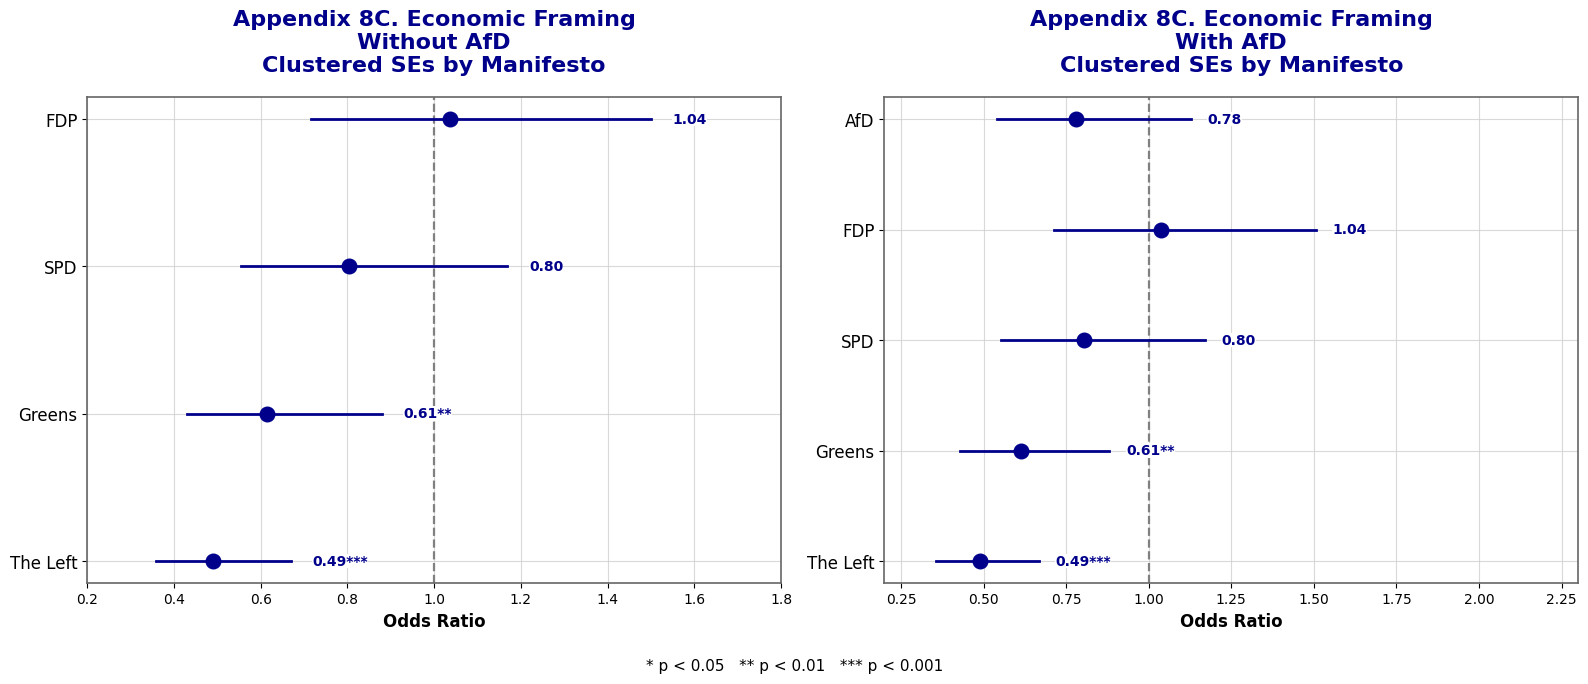

In [ ]:
# We used here the same code from the previous one; 
# but we changed only the frame, the title, and the color to create the same plot for the economic frame.

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


df = df_final.copy()

keep_parties = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP", "AfD"]

df["party_names"] = df["party_names"].astype(str).str.strip()
df = df[df["party_names"].isin(keep_parties)].copy()

df["predicted_label"] = (
    df["predicted_label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

label_map = {
    "humanitarian": "humanitarian",
    "economic": "economic",
    "security": "security",
    "securitroy": "security",
    "cultural": "cultural",
    "culturee": "cultural"
}

df["predicted_label"] = df["predicted_label"].replace(label_map)

valid_labels = ["humanitarian", "economic", "security", "cultural"]
df = df[df["predicted_label"].isin(valid_labels)].copy()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)


df["economic_binary"] = (df["predicted_label"] == "economic").astype(int)

df["year_centered"] = df["year"] - df["year"].mean()


df["manifesto_id"] = df["sentence_id"].astype(str).str.rsplit("_", n=1).str[0]

print("Number of manifesto clusters:", df["manifesto_id"].nunique())


def run_logit_manifesto_cluster(data, party_order, model_name):
    data = data.copy()

    data["party_names"] = pd.Categorical(
        data["party_names"],
        categories=party_order,
        ordered=True
    )

    X = pd.get_dummies(data["party_names"], drop_first=True, dtype=float)
    X["year_centered"] = data["year_centered"].astype(float)
    X = sm.add_constant(X, has_constant="add")

    y = data["economic_binary"].astype(int)
    groups = data["manifesto_id"]

    model = sm.Logit(y, X)

    result = model.fit(
        disp=False,
        cov_type="cluster",
        cov_kwds={"groups": groups}
    )

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(result.summary())

    return result


df_no_afd = df[df["party_names"] != "AfD"].copy()

party_order_no_afd = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP"]

result_no_afd = run_logit_manifesto_cluster(
    data=df_no_afd,
    party_order=party_order_no_afd,
    model_name="MODEL A: ECONOMIC vs OTHER FRAMES | WITHOUT AfD | CLUSTERED BY MANIFESTO"
)


df_with_afd = df.copy()

party_order_with_afd = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP", "AfD"]

result_with_afd = run_logit_manifesto_cluster(
    data=df_with_afd,
    party_order=party_order_with_afd,
    model_name="MODEL B: ECONOMIC vs OTHER FRAMES | WITH AfD | CLUSTERED BY MANIFESTO"
)


def extract_or_ci(logit_result, terms_to_keep):
    params = logit_result.params.copy()
    conf = logit_result.conf_int().copy()
    pvals = logit_result.pvalues.copy()

    lower_col = conf.columns[0]
    upper_col = conf.columns[1]

    out = pd.DataFrame({
        "term": params.index,
        "coef": params.values,
        "lower_coef": conf[lower_col].values,
        "upper_coef": conf[upper_col].values,
        "pval": pvals.values
    })

    out = out[out["term"].isin(terms_to_keep)].copy()

    out["odds_ratio"] = np.exp(out["coef"])
    out["lower"] = np.exp(out["lower_coef"])
    out["upper"] = np.exp(out["upper_coef"])

    def stars(p):
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return ""

    out["stars"] = out["pval"].apply(stars)

    return out

terms_no_afd = ["SPD", "Greens", "The Left", "FDP"]
terms_with_afd = ["SPD", "Greens", "The Left", "FDP", "AfD"]

or_no_afd = extract_or_ci(result_no_afd, terms_no_afd)
or_with_afd = extract_or_ci(result_with_afd, terms_with_afd)

print("\nOdds Ratios - Model A (without AfD)")
print(or_no_afd[["term", "odds_ratio", "lower", "upper", "pval", "stars"]])

print("\nOdds Ratios - Model B (with AfD)")
print(or_with_afd[["term", "odds_ratio", "lower", "upper", "pval", "stars"]])


plot_order_no_afd = ["FDP", "SPD", "Greens", "The Left"]
plot_order_with_afd = ["AfD", "FDP", "SPD", "Greens", "The Left"]

or_no_afd["term"] = pd.Categorical(
    or_no_afd["term"],
    categories=plot_order_no_afd,
    ordered=True
)
or_no_afd = or_no_afd.sort_values("term").reset_index(drop=True)

or_with_afd["term"] = pd.Categorical(
    or_with_afd["term"],
    categories=plot_order_with_afd,
    ordered=True
)
or_with_afd = or_with_afd.sort_values("term").reset_index(drop=True)


def forest_plot(ax, df_or, title, color, x_min=None, x_max=None):
    y = np.arange(len(df_or))

    ax.set_facecolor("white")
    ax.grid(True, axis="both", linestyle="-", linewidth=0.8, color="#d0d0d0", alpha=0.8)
    ax.set_axisbelow(True)

    for i, row in enumerate(df_or.itertuples()):
        ax.plot(
            [row.lower, row.upper],
            [i, i],
            color=color,
            linewidth=2.0,
            zorder=2
        )

    ax.scatter(df_or["odds_ratio"], y, color=color, s=110, zorder=3)
    ax.axvline(1, color="gray", linestyle="--", linewidth=1.6, zorder=1)

    ax.set_yticks(y)
    ax.set_yticklabels(df_or["term"], fontsize=12)
    ax.set_xlabel("Odds Ratio", fontsize=12, weight="bold")
    ax.set_title(title, fontsize=16, weight="bold", color=color, pad=18)

    ax.invert_yaxis()

    if x_min is None:
        x_min = max(0, df_or["lower"].min() - 0.15)
    if x_max is None:
        x_max = df_or["upper"].max() + 0.4

    ax.set_xlim(x_min, x_max)

    for i, row in enumerate(df_or.itertuples()):
        label = f"{row.odds_ratio:.2f}{row.stars}"
        x_left, x_right = ax.get_xlim()

        if row.odds_ratio > x_right * 0.75:
            x_text = row.odds_ratio - 0.15
            ha = "right"
        else:
            x_text = min(row.upper + 0.05, x_right - 0.10)
            ha = "left"

        ax.text(
            x_text,
            i,
            label,
            va="center",
            ha=ha,
            fontsize=10,
            color=color,
            weight="bold",
            bbox=dict(facecolor="white", edgecolor="none", pad=0.2)
        )

    for spine in ax.spines.values():
        spine.set_color("#666666")
        spine.set_linewidth(1.2)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("white")

forest_plot(
    axes[0],
    or_no_afd,
    "Appendix 8C. Economic Framing\nWithout AfD\nClustered SEs by Manifesto",
    color="darkblue",
    x_min=0.2,
    x_max=max(or_no_afd["upper"].max() + 0.3, 1.8)
)

forest_plot(
    axes[1],
    or_with_afd,
    "Appendix 8C. Economic Framing\nWith AfD\nClustered SEs by Manifesto",
    color="darkblue",
    x_min=0.2,
    x_max=max(or_with_afd["upper"].max() + 0.3, 2.3)
)

fig.text(
    0.5,
    0.04,
    "* p < 0.05   ** p < 0.01   *** p < 0.001",
    ha="center",
    va="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.07, 1, 1])

plt.savefig("appendix8_economic.png", dpi=300, bbox_inches="tight")
plt.savefig("appendix8_economic.pdf", dpi=300, bbox_inches="tight")
plt.show()

Number of manifesto clusters: 44

MODEL A: CULTURAL vs OTHER FRAMES | WITHOUT AfD | CLUSTERED BY MANIFESTO
                           Logit Regression Results                           
Dep. Variable:        cultural_binary   No. Observations:                 2782
Model:                          Logit   Df Residuals:                     2776
Method:                           MLE   Df Model:                            5
Date:                Sat, 25 Apr 2026   Pseudo R-squ.:                 0.01946
Time:                        19:53:31   Log-Likelihood:                -1625.8
converged:                       True   LL-Null:                       -1658.1
Covariance Type:              cluster   LLR p-value:                 1.393e-12
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const            -0.7582      0.218     -3.481      0.000      -1.185      -0.331
SPD            

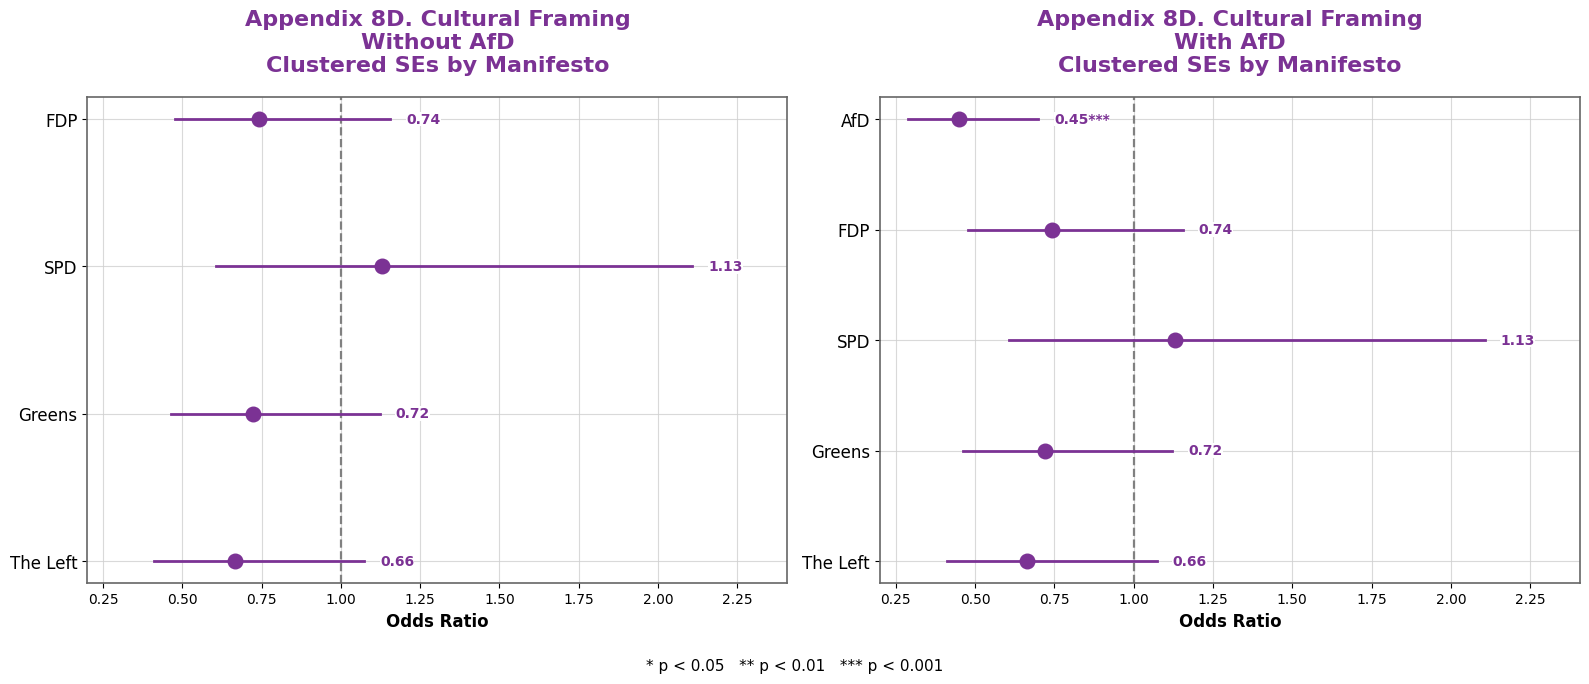

In [ ]:
# We used here the same code from the previous one; 
# but we changed only the frame, the title, and the color to create the same plot for the cultural frame.


import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt


df = df_final.copy()

keep_parties = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP", "AfD"]

df["party_names"] = df["party_names"].astype(str).str.strip()
df = df[df["party_names"].isin(keep_parties)].copy()

df["predicted_label"] = (
    df["predicted_label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

label_map = {
    "humanitarian": "humanitarian",
    "economic": "economic",
    "security": "security",
    "securitroy": "security",
    "cultural": "cultural",
    "culturee": "cultural"
}

df["predicted_label"] = df["predicted_label"].replace(label_map)

valid_labels = ["humanitarian", "economic", "security", "cultural"]
df = df[df["predicted_label"].isin(valid_labels)].copy()

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)


df["cultural_binary"] = (df["predicted_label"] == "cultural").astype(int)

df["year_centered"] = df["year"] - df["year"].mean()


df["manifesto_id"] = df["sentence_id"].astype(str).str.rsplit("_", n=1).str[0]

print("Number of manifesto clusters:", df["manifesto_id"].nunique())

def run_logit_manifesto_cluster(data, party_order, model_name):
    data = data.copy()

    data["party_names"] = pd.Categorical(
        data["party_names"],
        categories=party_order,
        ordered=True
    )

    X = pd.get_dummies(data["party_names"], drop_first=True, dtype=float)
    X["year_centered"] = data["year_centered"].astype(float)
    X = sm.add_constant(X, has_constant="add")

    y = data["cultural_binary"].astype(int)
    groups = data["manifesto_id"]

    model = sm.Logit(y, X)

    result = model.fit(
        disp=False,
        cov_type="cluster",
        cov_kwds={"groups": groups}
    )

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(result.summary())

    return result


df_no_afd = df[df["party_names"] != "AfD"].copy()

party_order_no_afd = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP"]

result_no_afd = run_logit_manifesto_cluster(
    data=df_no_afd,
    party_order=party_order_no_afd,
    model_name="MODEL A: CULTURAL vs OTHER FRAMES | WITHOUT AfD | CLUSTERED BY MANIFESTO"
)


df_with_afd = df.copy()

party_order_with_afd = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP", "AfD"]

result_with_afd = run_logit_manifesto_cluster(
    data=df_with_afd,
    party_order=party_order_with_afd,
    model_name="MODEL B: CULTURAL vs OTHER FRAMES | WITH AfD | CLUSTERED BY MANIFESTO"
)

def extract_or_ci(logit_result, terms_to_keep):
    params = logit_result.params.copy()
    conf = logit_result.conf_int().copy()
    pvals = logit_result.pvalues.copy()

    lower_col = conf.columns[0]
    upper_col = conf.columns[1]

    out = pd.DataFrame({
        "term": params.index,
        "coef": params.values,
        "lower_coef": conf[lower_col].values,
        "upper_coef": conf[upper_col].values,
        "pval": pvals.values
    })

    out = out[out["term"].isin(terms_to_keep)].copy()

    out["odds_ratio"] = np.exp(out["coef"])
    out["lower"] = np.exp(out["lower_coef"])
    out["upper"] = np.exp(out["upper_coef"])

    def stars(p):
        if p < 0.001:
            return "***"
        elif p < 0.01:
            return "**"
        elif p < 0.05:
            return "*"
        else:
            return ""

    out["stars"] = out["pval"].apply(stars)

    return out

terms_no_afd = ["SPD", "Greens", "The Left", "FDP"]
terms_with_afd = ["SPD", "Greens", "The Left", "FDP", "AfD"]

or_no_afd = extract_or_ci(result_no_afd, terms_no_afd)
or_with_afd = extract_or_ci(result_with_afd, terms_with_afd)

print("\nOdds Ratios - Model A (without AfD)")
print(or_no_afd[["term", "odds_ratio", "lower", "upper", "pval", "stars"]])

print("\nOdds Ratios - Model B (with AfD)")
print(or_with_afd[["term", "odds_ratio", "lower", "upper", "pval", "stars"]])


plot_order_no_afd = ["FDP", "SPD", "Greens", "The Left"]
plot_order_with_afd = ["AfD", "FDP", "SPD", "Greens", "The Left"]

or_no_afd["term"] = pd.Categorical(
    or_no_afd["term"],
    categories=plot_order_no_afd,
    ordered=True
)
or_no_afd = or_no_afd.sort_values("term").reset_index(drop=True)

or_with_afd["term"] = pd.Categorical(
    or_with_afd["term"],
    categories=plot_order_with_afd,
    ordered=True
)
or_with_afd = or_with_afd.sort_values("term").reset_index(drop=True)


def forest_plot(ax, df_or, title, color, x_min=None, x_max=None):
    y = np.arange(len(df_or))

    ax.set_facecolor("white")
    ax.grid(True, axis="both", linestyle="-", linewidth=0.8, color="#d0d0d0", alpha=0.8)
    ax.set_axisbelow(True)

    for i, row in enumerate(df_or.itertuples()):
        ax.plot(
            [row.lower, row.upper],
            [i, i],
            color=color,
            linewidth=2.0,
            zorder=2
        )

    ax.scatter(df_or["odds_ratio"], y, color=color, s=110, zorder=3)
    ax.axvline(1, color="gray", linestyle="--", linewidth=1.6, zorder=1)

    ax.set_yticks(y)
    ax.set_yticklabels(df_or["term"], fontsize=12)
    ax.set_xlabel("Odds Ratio", fontsize=12, weight="bold")
    ax.set_title(title, fontsize=16, weight="bold", color=color, pad=18)

    ax.invert_yaxis()

    if x_min is None:
        x_min = max(0, df_or["lower"].min() - 0.15)
    if x_max is None:
        x_max = df_or["upper"].max() + 0.4

    ax.set_xlim(x_min, x_max)

    for i, row in enumerate(df_or.itertuples()):
        label = f"{row.odds_ratio:.2f}{row.stars}"
        x_left, x_right = ax.get_xlim()

        if row.odds_ratio > x_right * 0.75:
            x_text = row.odds_ratio - 0.15
            ha = "right"
        else:
            x_text = min(row.upper + 0.05, x_right - 0.10)
            ha = "left"

        ax.text(
            x_text,
            i,
            label,
            va="center",
            ha=ha,
            fontsize=10,
            color=color,
            weight="bold",
            bbox=dict(facecolor="white", edgecolor="none", pad=0.2)
        )

    for spine in ax.spines.values():
        spine.set_color("#666666")
        spine.set_linewidth(1.2)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor("white")

forest_plot(
    axes[0],
    or_no_afd,
    "Appendix 8D. Cultural Framing\nWithout AfD\nClustered SEs by Manifesto",
    color="#7B3294",
    x_min=0.2,
    x_max=max(or_no_afd["upper"].max() + 0.3, 1.8)
)

forest_plot(
    axes[1],
    or_with_afd,
    "Appendix 8D. Cultural Framing\nWith AfD\nClustered SEs by Manifesto",
    color="#7B3294",
    x_min=0.2,
    x_max=max(or_with_afd["upper"].max() + 0.3, 2.3)
)

fig.text(
    0.5,
    0.04,
    "* p < 0.05   ** p < 0.01   *** p < 0.001",
    ha="center",
    va="center",
    fontsize=11
)

plt.tight_layout(rect=[0, 0.07, 1, 1])

plt.savefig("appendix8_clutral.png", dpi=300, bbox_inches="tight")
plt.savefig("appendix8_clutral.pdf", dpi=300, bbox_inches="tight")


plt.show()

# Multinomenial Regression Analysis with Clustered Standard Errors by Manifestos (with and without AFD)

In [ ]:
# for our main analysis in the text, we decide to have the multinomial logit model with clustered standard errors by manifesto,
# because it will be easy read and interpret. 
# We used ChatGPT to get this code. the used prompt: 
# "Now we want to run a multinomial logit model with clustered standard errors by manifesto, with a reference category of "economic" frame, 
# and with reference category of "CDU/CSU" for the parties. We want to run two models: one with AfD and one without AfD.
# Please write the code for this analysis, and make sure to clean the data as we did before, here is used code for the binary logit models,
#  you can use it as a template and modify it for the multinomial logit model". 


import pandas as pd
import numpy as np
import statsmodels.api as sm

df = df_final.copy()

keep_parties = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP", "AfD"]

df["party_names"] = df["party_names"].astype(str).str.strip()
df = df[df["party_names"].isin(keep_parties)].copy()

df["predicted_label"] = (
    df["predicted_label"]
    .astype(str)
    .str.strip()
    .str.lower()
)

label_map = {
    "humanitarian": "humanitarian",
    "economic": "economic",
    "security": "security",
    "securitroy": "security",
    "cultural": "cultural",
    "culturee": "cultural"
}

df["predicted_label"] = df["predicted_label"].replace(label_map)

valid_labels = ["economic", "security", "humanitarian", "cultural"]
df = df[df["predicted_label"].isin(valid_labels)].copy()


df["frame"] = pd.Categorical(
    df["predicted_label"],
    categories=["economic", "security", "humanitarian", "cultural"] # reference category will be "economic"
)

df["year"] = pd.to_numeric(df["year"], errors="coerce")
df = df.dropna(subset=["year"]).copy()
df["year"] = df["year"].astype(int)

df["year_centered"] = df["year"] - df["year"].mean()

df["manifesto_id"] = df["sentence_id"].astype(str).str.rsplit("_", n=1).str[0]

print("Number of manifesto clusters:", df["manifesto_id"].nunique())
print("\nManifesto cluster sizes:")
print(df["manifesto_id"].value_counts().head())


def run_mnlogit_manifesto_cluster(data, parties_order, model_name):
    data = data.copy()

    data["party_names"] = pd.Categorical(
        data["party_names"],
        categories=parties_order,
        ordered=True
    )

    X = pd.get_dummies(data["party_names"], drop_first=True, dtype=float) # reference category will be the first one in the parties_order list which is "CDU/CSU".
    X["year_centered"] = data["year_centered"].astype(float)
    X = sm.add_constant(X, has_constant="add")

    y = data["frame"]

    model = sm.MNLogit(y, X)

    result = model.fit(
        maxiter=100,
        disp=False,
        cov_type="cluster",
        cov_kwds={"groups": data["manifesto_id"]}
    )

    print("\n" + "=" * 80)
    print(model_name)
    print("=" * 80)
    print(result.summary())

    return result

df_no_afd = df[df["party_names"] != "AfD"].copy()

order_no_afd = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP"]

result_no_afd = run_mnlogit_manifesto_cluster(
    data=df_no_afd,
    parties_order=order_no_afd,
    model_name="MULTINOMIAL MODEL A: WITHOUT AfD | CLUSTERED SEs BY MANIFESTO"
)


df_with_afd = df.copy()

order_with_afd = ["CDU/CSU", "SPD", "Greens", "The Left", "FDP", "AfD"]

result_with_afd = run_mnlogit_manifesto_cluster(
    data=df_with_afd,
    parties_order=order_with_afd,
    model_name="MULTINOMIAL MODEL B: WITH AfD | CLUSTERED SEs BY MANIFESTO"
)

Number of manifesto clusters: 44

Manifesto cluster sizes:
manifesto_id
41113_2017    249
41953_2025    194
41113_2021    168
41223_2017    161
41953_2021    161
Name: count, dtype: int64

MULTINOMIAL MODEL A: WITHOUT AfD | CLUSTERED SEs BY MANIFESTO
                          MNLogit Regression Results                          
Dep. Variable:                  frame   No. Observations:                 2782
Model:                        MNLogit   Df Residuals:                     2764
Method:                           MLE   Df Model:                           15
Date:                Fri, 01 May 2026   Pseudo R-squ.:                 0.03395
Time:                        16:20:32   Log-Likelihood:                -3576.3
converged:                       True   LL-Null:                       -3701.9
Covariance Type:              cluster   LLR p-value:                 6.497e-45
    frame=security       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------

In [ ]:
# then we want to get a table include all regression results for the two models, 
# with coefficients, standard errors, p-values, significance stars, RRRs, and confidence intervals for the RRRs, 
# in order to put it in the appendix. 

# so, we used ChatGPT to write generate a code for this, the used prompt:
# "Now the multinomial regression analysis is done, we want to extract the results into a clean long-format table, 
# with columns for model name, outcome category, term, coefficient, standard error, p-value, significance stars, RRR, and confidence 
# intervals for the RRR. The reference outcome category is "economic", and the reference party is "CDU/CSU". 
# Please write a code to do this for both models (with and without AfD)."


def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""

def extract_mnlogit_appendix_table(result, model_label):
    """
    Extracts MNLogit results into a clean long-format table.
    Reference outcome = economic
    Reference party = CDU/CSU
    """

    params = result.params.copy()
    ses = result.bse.copy()
    pvals = result.pvalues.copy()
    conf = result.conf_int().copy()

    outcome_map = {
        params.columns[0]: "Security vs Economic",
        params.columns[1]: "Humanitarian vs Economic",
        params.columns[2]: "Cultural vs Economic"
    }

    rows = []

    for col in params.columns:
        outcome_name = outcome_map[col]

        for term in params.index:
            coef = params.loc[term, col]
            se = ses.loc[term, col]
            pval = pvals.loc[term, col]

            try:
                lower = conf.loc[(col, term), "lower"]
                upper = conf.loc[(col, term), "upper"]
            except:
                try:
                    lower = conf.loc[(col, term), 0]
                    upper = conf.loc[(col, term), 1]
                except:
                    lower = np.nan
                    upper = np.nan

            rows.append({
                "Model": model_label,
                "Outcome": outcome_name,
                "Term": term,
                "Coefficient": coef,
                "Clustered SE": se,
                "p-value": pval,
                "Stars": significance_stars(pval),
                "RRR": np.exp(coef),
                "95% CI Lower": np.exp(lower),
                "95% CI Upper": np.exp(upper)
            })

    table = pd.DataFrame(rows)

    table["Coefficient"] = table["Coefficient"].round(3)
    table["Clustered SE"] = table["Clustered SE"].round(3)
    table["p-value"] = table["p-value"].round(3)
    table["RRR"] = table["RRR"].round(3)
    table["95% CI Lower"] = table["95% CI Lower"].round(3)
    table["95% CI Upper"] = table["95% CI Upper"].round(3)

    return table


table_no_afd = extract_mnlogit_appendix_table(
    result_no_afd,
    "Model A: Without AfD"
)

table_with_afd = extract_mnlogit_appendix_table(
    result_with_afd,
    "Model B: With AfD"
)

appendix_table = pd.concat([table_no_afd, table_with_afd], ignore_index=True)

print(appendix_table)

                   Model                   Outcome           Term  \
0   Model A: Without AfD      Security vs Economic          const   
1   Model A: Without AfD      Security vs Economic            SPD   
2   Model A: Without AfD      Security vs Economic         Greens   
3   Model A: Without AfD      Security vs Economic       The Left   
4   Model A: Without AfD      Security vs Economic            FDP   
5   Model A: Without AfD      Security vs Economic  year_centered   
6   Model A: Without AfD  Humanitarian vs Economic          const   
7   Model A: Without AfD  Humanitarian vs Economic            SPD   
8   Model A: Without AfD  Humanitarian vs Economic         Greens   
9   Model A: Without AfD  Humanitarian vs Economic       The Left   
10  Model A: Without AfD  Humanitarian vs Economic            FDP   
11  Model A: Without AfD  Humanitarian vs Economic  year_centered   
12  Model A: Without AfD      Cultural vs Economic          const   
13  Model A: Without AfD      Cult

In [ ]:
# to save the table in both csv and excel formats for the appendix (this is done without any assistance from AI tools)

appendix_table.to_csv("appendix_multinomial_regression_table.csv", index=False)
appendix_table.to_excel("appendix_multinomial_regression_table.xlsx", index=False)

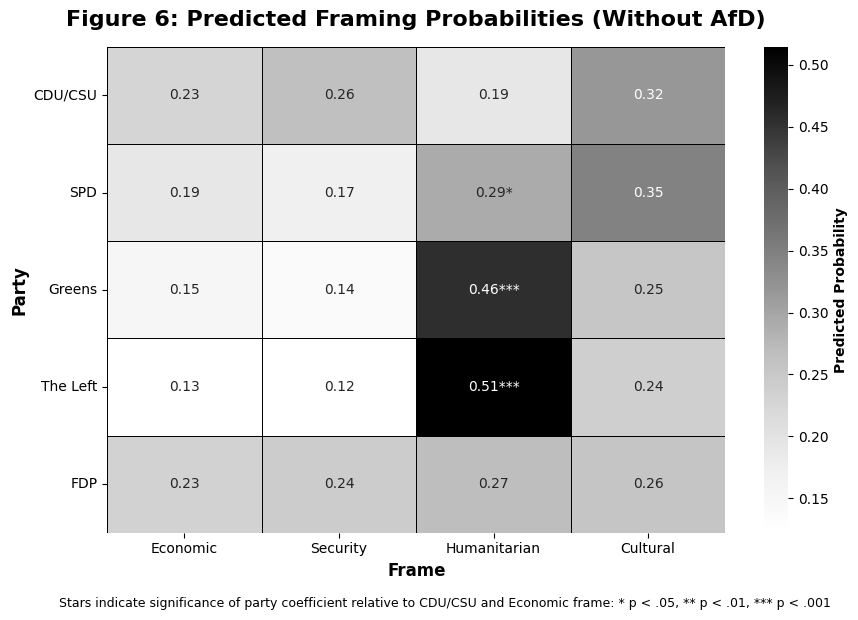

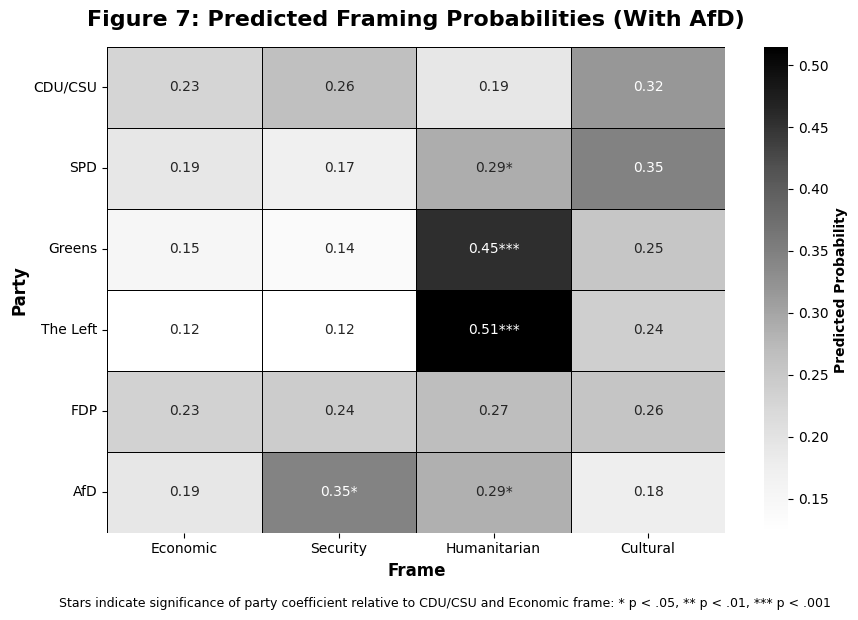

In [ ]:
# in stead of presenting the regression results in a long table in the main text of our project. We decided to present the predicted probabilities of 
# each frame for each party in a heatmap, and we will put the long table with all regression results in the appendix.


# We used ChatGPT to write the code for this, the used prompt:
# "Now we want to create a heatmap to visualize the predicted probabilities of each frame for 
# each party based on the multinomial logit models we ran before. We want to create two heatmaps: 
# one for the model without AfD and one for the model with AfD. 
# And we want to add significance stars to indicate which coefficients are statistically significant compared to the reference category
# (CDU/CSU and Economic frame). Please write a code to do this. The heatmaps should have a title, and the x-axis should be the frames, 
# and the y-axis should be the parties. The color of the heatmap should be greyscale with a legend. 
# The annotations should show the predicted probabilities"

# For sure we changed abit the title, some font sizes to make it more visually appealing, but the main code is generated by ChatGPT.

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.api as sm

frame_order = ["Economic", "Security", "Humanitarian", "Cultural"]

def get_predicted_probs(result, parties_order):
    df_pred = pd.DataFrame({
        "party_names": parties_order,
        "year_centered": 0
    })

    df_pred["party_names"] = pd.Categorical(
        df_pred["party_names"],
        categories=parties_order,
        ordered=True
    )

    X_pred = pd.get_dummies(df_pred["party_names"], drop_first=True, dtype=float)
    X_pred["year_centered"] = 0
    X_pred = sm.add_constant(X_pred, has_constant="add")
    X_pred = X_pred.reindex(columns=result.model.exog_names, fill_value=0)

    probs = result.predict(X_pred)
    probs.columns = frame_order
    probs["Party"] = parties_order

    return probs


def significance_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""


def make_heatmap_annotations(probs, result, parties_order):
    annotations = probs.set_index("Party")[frame_order].copy().astype(str)

    for party in parties_order:
        for frame in frame_order:
            value = probs.loc[probs["Party"] == party, frame].iloc[0]

            if party == "CDU/CSU" or frame == "Economic":
                stars = ""
            else:
                frame_to_col = {
                    "Security": result.params.columns[0],
                    "Humanitarian": result.params.columns[1],
                    "Cultural": result.params.columns[2]
                }

                try:
                    pval = result.pvalues.loc[party, frame_to_col[frame]]
                    stars = significance_stars(pval)
                except Exception:
                    stars = ""

            annotations.loc[party, frame] = f"{value:.2f}{stars}"

    return annotations


def plot_heatmap_with_stars(probs, result, parties_order, title, filename_base=None):
    plot_data = probs.set_index("Party")[frame_order]
    annotations = make_heatmap_annotations(probs, result, parties_order)

    plt.figure(figsize=(9, 6))
    sns.heatmap(
        plot_data,
        annot=annotations,
        fmt="",
        cmap="Greys",
        linewidths=0.6,
        linecolor="black",
        cbar_kws={"label": "Predicted Probability"}
    )

    plt.title(title, fontsize=16, weight="bold", pad=15)
    plt.xlabel("Frame", fontsize=12, weight="bold")
    plt.ylabel("Party", fontsize=12, weight="bold")
    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    plt.figtext(
        0.5, -0.02,
        "Stars indicate significance of party coefficient relative to CDU/CSU and Economic frame: * p < .05, ** p < .01, *** p < .001",
        ha="center",
        fontsize=9
    )

    plt.tight_layout()

    if filename_base is not None:
        plt.savefig(f"{filename_base}.png", dpi=300, bbox_inches="tight")
        plt.savefig(f"{filename_base}.pdf", bbox_inches="tight")

    plt.show()

probs_no_afd = get_predicted_probs(result_no_afd, order_no_afd)
probs_with_afd = get_predicted_probs(result_with_afd, order_with_afd)


plot_heatmap_with_stars(
    probs_no_afd,
    result_no_afd,
    order_no_afd,
    "Figure 6: Predicted Framing Probabilities (Without AfD)",
    filename_base="figure_6_heatmap_no_afd"
)

plot_heatmap_with_stars(
    probs_with_afd,
    result_with_afd,
    order_with_afd,
    "Figure 7: Predicted Framing Probabilities (With AfD)",
    filename_base="figure_7_heatmap_with_afd"
)